In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

from utils import one_hot_encode

from linear_model import train_linear_model, predict, accuracy

from mlp_model import (
    train_mlp_1_hidden,
    predict_1_hidden,
    train_mlp_2_hidden,
    predict_2_hidden
)

from random_search_utils import (
    create_train_valid_split,
    random_search_linear_model,
    random_search_mlp_1_hidden,
    random_search_mlp_2_hidden,
    results_to_dataframe,
    save_results,
    load_results
)

## 2. Chargement et préparation des données

In [4]:
# =========================
# Chargement MNIST
# =========================

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalisation
X_train = X_train.astype(np.float64) / 255.0
X_test = X_test.astype(np.float64) / 255.0

# Aplatissement
X_train_flat = X_train.reshape(X_train.shape[0], 28 * 28)
X_test_flat = X_test.reshape(X_test.shape[0], 28 * 28)

# One-hot encoding
Y_train = one_hot_encode(y_train, num_classes=10)
Y_test = one_hot_encode(y_test, num_classes=10)

print("X_train_flat :", X_train_flat.shape)
print("Y_train :", Y_train.shape)
print("X_test_flat :", X_test_flat.shape)
print("Y_test :", Y_test.shape)

X_train_flat : (60000, 784)
Y_train : (60000, 10)
X_test_flat : (10000, 784)
Y_test : (10000, 10)


In [6]:
# =========================
# Split train / validation
# =========================

X_train_sub, Y_train_sub, y_train_sub, X_valid, Y_valid, y_valid = create_train_valid_split(
    X_train_flat,
    Y_train,
    y_train,
    valid_size=10000
)

print("X_train_sub :", X_train_sub.shape)
print("Y_train_sub :", Y_train_sub.shape)
print("X_valid :", X_valid.shape)
print("y_valid :", y_valid.shape)

X_train_sub : (50000, 784)
Y_train_sub : (50000, 10)
X_valid : (10000, 784)
y_valid : (10000,)


## 3. GridSearch 1 MLP1

In [7]:
best_mlp1, results_mlp1 = random_search_mlp_1_hidden(
    X_train_sub,
    Y_train_sub,
    X_valid,
    y_valid,
    train_mlp_1_hidden=train_mlp_1_hidden,
    predict_1_hidden=predict_1_hidden,
    accuracy=accuracy,
    n_trials=8,
    hidden_dim_choices=(128, 256),
    learning_rate_choices=(0.05, 0.01),
    epochs_choices=(100, 150),
    save_path="results_mlp1_targeted.pkl",
    seed=202
)

save_results("all_mlp1_targeted.pkl", {
    "best_mlp1": best_mlp1,
    "results_mlp1": results_mlp1
})


=== MLP 1 couche cachée - Essai 1/8 ===
hidden_dim = 256
learning_rate = 0.01
epochs = 150


KeyboardInterrupt: 

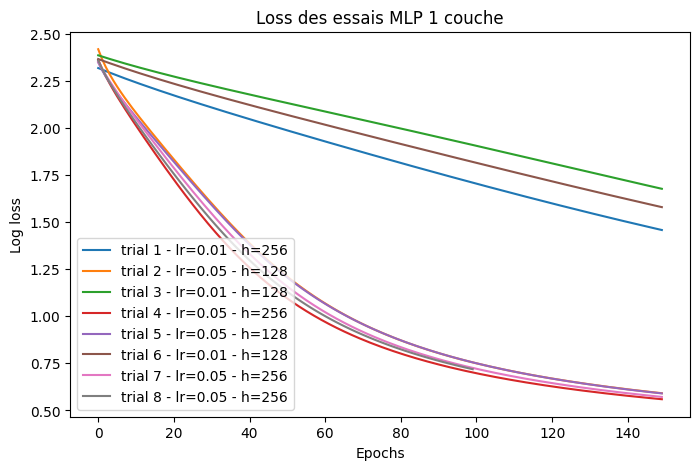

In [11]:
plt.figure(figsize=(8, 5))

for result in results_mlp1:
    label = f"trial {result['trial']} - lr={result['params']['learning_rate']} - h={result['params']['hidden_dim']}"
    plt.plot(result["loss_history"], label=label)

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss des essais MLP 1 couche")
plt.legend()
plt.show()

In [12]:
for lr in [0.1, 0.05, 0.02]:
    A1, b1, A2, b2, loss_history = train_mlp_1_hidden(
        X_train_sub,
        Y_train_sub,
        input_dim=784,
        hidden_dim=256,
        num_classes=10,
        learning_rate=lr,
        epochs=100
    )

    y_pred_valid = predict_1_hidden(X_valid, A1, b1, A2, b2)
    acc_valid = accuracy(y_valid, y_pred_valid)

    print("lr =", lr)
    print("valid accuracy =", acc_valid)
    print("première loss =", loss_history[0])
    print("dernière loss =", loss_history[-1])
    print()

lr = 0.1
valid accuracy = 0.8881
première loss = 2.3932091649205196
dernière loss = 0.49676315021682343

lr = 0.05
valid accuracy = 0.8624
première loss = 2.427698804107109
dernière loss = 0.7321466645679119

lr = 0.02
valid accuracy = 0.7895
première loss = 2.3210546720884837
dernière loss = 1.26929640983551



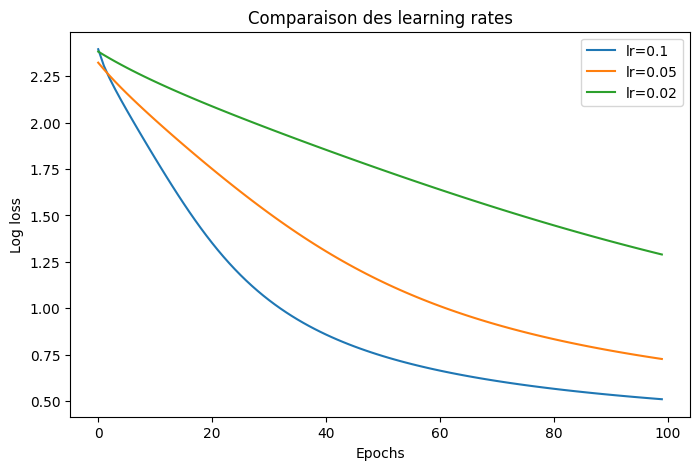

In [14]:
plt.figure(figsize=(8, 5))

for lr in [0.1, 0.05, 0.02]:
    A1, b1, A2, b2, loss_history = train_mlp_1_hidden(
        X_train_sub,
        Y_train_sub,
        input_dim=784,
        hidden_dim=256,
        num_classes=10,
        learning_rate=lr,
        epochs=100
    )

    plt.plot(loss_history, label=f"lr={lr}")

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Comparaison des learning rates")
plt.legend()
plt.show()

In [15]:
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(label, count, round(count / len(y_train), 4))

0 5923 0.0987
1 6742 0.1124
2 5958 0.0993
3 6131 0.1022
4 5842 0.0974
5 5421 0.0904
6 5918 0.0986
7 6265 0.1044
8 5851 0.0975
9 5949 0.0992


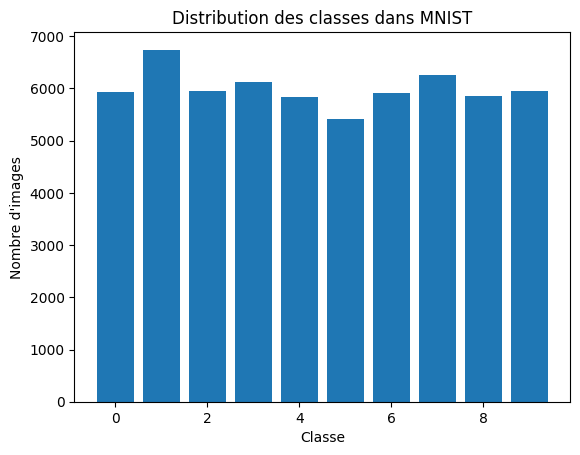

In [16]:
plt.bar(unique, counts)
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.title("Distribution des classes dans MNIST")
plt.show()

In [17]:
best_mlp1_long, results_mlp1_long = random_search_mlp_1_hidden(
    X_train_sub,
    Y_train_sub,
    X_valid,
    y_valid,
    train_mlp_1_hidden=train_mlp_1_hidden,
    predict_1_hidden=predict_1_hidden,
    accuracy=accuracy,
    n_trials=10,
    hidden_dim_choices=(128, 256, 512),
    learning_rate_choices=(0.1, 0.05, 0.02),
    epochs_choices=(150, 200, 300),
    save_path="results_mlp1_long.pkl",
    seed=707
)


=== MLP 1 couche cachée - Essai 1/10 ===
hidden_dim = 128
learning_rate = 0.02
epochs = 300
Validation accuracy : 0.8576
Final loss : 0.7098506119230166
Temps : 203.36 s

=== MLP 1 couche cachée - Essai 2/10 ===
hidden_dim = 256
learning_rate = 0.02
epochs = 300
Validation accuracy : 0.8732
Final loss : 0.6435373411836124
Temps : 360.7 s

=== MLP 1 couche cachée - Essai 3/10 ===
hidden_dim = 512
learning_rate = 0.05
epochs = 300
Validation accuracy : 0.9064
Final loss : 0.40048365369573546
Temps : 529.07 s

=== MLP 1 couche cachée - Essai 4/10 ===
hidden_dim = 128
learning_rate = 0.02
epochs = 300
Validation accuracy : 0.8646
Final loss : 0.6569082218997178
Temps : 159.28 s

=== MLP 1 couche cachée - Essai 5/10 ===
hidden_dim = 512
learning_rate = 0.02
epochs = 200
Validation accuracy : 0.8519
Final loss : 0.7598757208197887
Temps : 355.05 s

=== MLP 1 couche cachée - Essai 6/10 ===
hidden_dim = 128
learning_rate = 0.05
epochs = 200
Validation accuracy : 0.8878
Final loss : 0.50672707

## 1. Fine-tunning du modele lineaie

In [32]:
best_linear_final_search, results_linear_final_search = random_search_linear_model(
    X_train_sub,
    Y_train_sub,
    X_valid,
    y_valid,
    train_linear_model=train_linear_model,
    predict=predict,
    accuracy=accuracy,
    n_trials=8,
    learning_rate_choices=(1.0, 0.5, 0.2, 0.1, 0.05, 0.01),
    epochs_choices=(500,),
    save_path="results_linear_final_search.pkl",
    seed=1801
)


=== Modèle linéaire - Essai 1/8 ===
learning_rate = 1.0
epochs = 500
Validation accuracy : 0.9229
Final loss : 0.2867261518502953
Temps : 83.68 s

=== Modèle linéaire - Essai 2/8 ===
learning_rate = 1.0
epochs = 500
Validation accuracy : 0.923
Final loss : 0.2867076004091716
Temps : 60.79 s

=== Modèle linéaire - Essai 3/8 ===
learning_rate = 0.1
epochs = 500
Validation accuracy : 0.9057
Final loss : 0.3978752154188712
Temps : 51.29 s

=== Modèle linéaire - Essai 4/8 ===
learning_rate = 0.01
epochs = 500
Validation accuracy : 0.8586
Final loss : 0.8113039067037697
Temps : 50.36 s

=== Modèle linéaire - Essai 5/8 ===
learning_rate = 0.5
epochs = 500
Validation accuracy : 0.919
Final loss : 0.3088209945195747
Temps : 61.36 s

=== Modèle linéaire - Essai 6/8 ===
learning_rate = 0.05
epochs = 500
Validation accuracy : 0.8936
Final loss : 0.4673802280772655
Temps : 61.86 s

=== Modèle linéaire - Essai 7/8 ===
learning_rate = 1.0
epochs = 500
Validation accuracy : 0.9232
Final loss : 0.2866

In [33]:
df_linear_final = results_to_dataframe(results_linear_final_search)

df_linear_final[
    [
        "trial",
        "valid_accuracy",
        "final_loss",
        "time_sec",
        "learning_rate",
        "epochs"
    ]
].sort_values(by="valid_accuracy", ascending=False)

,trial,valid_accuracy,final_loss,time_sec,learning_rate,epochs
6,7,0.9232,0.286694,43.445793,1.00,500
1,2,0.9230,0.286708,60.788902,1.00,500
0,1,0.9229,0.286726,83.677335,1.00,500
4,5,0.9190,0.308821,61.364449,0.50,500
7,8,0.9182,0.308819,62.652611,0.50,500
2,3,0.9057,0.397875,51.285330,0.10,500
5,6,0.8936,0.467380,61.857995,0.05,500
3,4,0.8586,0.811304,50.357136,0.01,500


In [34]:
print("Meilleur modèle linéaire")
print("Validation accuracy :", best_linear_final_search["valid_accuracy"])
print("Final loss :", best_linear_final_search["final_loss"])
print("Temps :", round(best_linear_final_search["time_sec"], 2), "s")
print("Paramètres :", best_linear_final_search["params"])

Meilleur modèle linéaire
Validation accuracy : 0.9232
Final loss : 0.2866937719578385
Temps : 43.45 s
Paramètres : {'learning_rate': 1.0, 'epochs': 500}


In [35]:
params = best_linear_final_search["best_parameters"]

y_pred_test_linear_final = predict(
    X_test_flat,
    params["A"],
    params["b"]
)

acc_test_linear_final = accuracy(y_test, y_pred_test_linear_final)

print("Accuracy test modèle linéaire final :", acc_test_linear_final)

Accuracy test modèle linéaire final : 0.9215


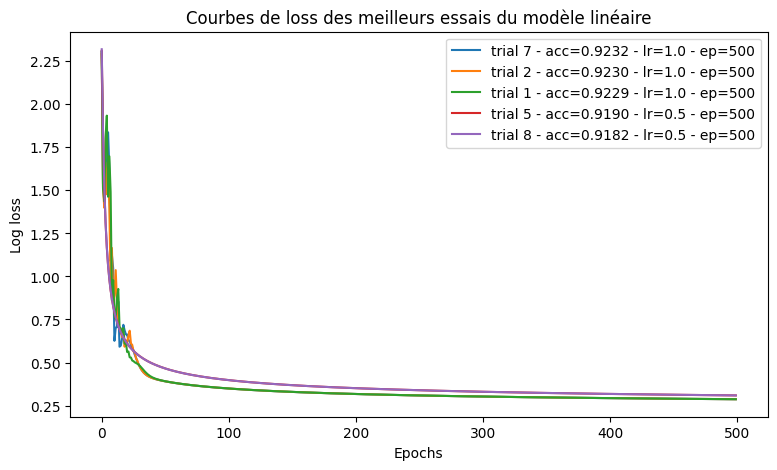

In [36]:
top5_linear = sorted(
    results_linear_final_search,
    key=lambda r: r["valid_accuracy"],
    reverse=True
)[:5]

plt.figure(figsize=(9, 5))

for result in top5_linear:
    label = (
        f"trial {result['trial']} - "
        f"acc={result['valid_accuracy']:.4f} - "
        f"lr={result['params']['learning_rate']} - "
        f"ep={result['params']['epochs']}"
    )
    plt.plot(result["loss_history"], label=label)

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Courbes de loss des meilleurs essais du modèle linéaire")
plt.legend()
plt.show()

Pour le modèle linéaire, les meilleurs résultats sont obtenus avec un learning rate élevé. Cependant, la courbe de loss montre une certaine instabilité, ce qui indique que le pas d’apprentissage est proche de la limite acceptable. Nous avons donc aussi observé la loss afin de ne pas sélectionner uniquement un modèle sur l’accuracy.

# 2. Fine-Tunning du mlp1

In [23]:
 best_mlp1_final_search, results_mlp1_final_search = random_search_mlp_1_hidden(
    X_train_sub,
    Y_train_sub,
    X_valid,
    y_valid,
    train_mlp_1_hidden=train_mlp_1_hidden,
    predict_1_hidden=predict_1_hidden,
    accuracy=accuracy,
    n_trials=10,
    hidden_dim_choices=(256, 512, 768),
    learning_rate_choices=(0.05, 0.1, 0.15, 0.2),
    epochs_choices=(350,),
    save_path="results_mlp1_final_search.pkl",
    seed=1601
)

save_results("all_mlp1_final_search.pkl", {
    "best_mlp1": best_mlp1_final_search,
    "results_mlp1": results_mlp1_final_search
})


=== MLP 1 couche cachée - Essai 1/10 ===
hidden_dim = 512
learning_rate = 0.2
epochs = 350
Validation accuracy : 0.9357
Final loss : 0.24748136568569506
Temps : 368.32 s

=== MLP 1 couche cachée - Essai 2/10 ===
hidden_dim = 768
learning_rate = 0.1
epochs = 350
Validation accuracy : 0.9232
Final loss : 0.3006214678138087
Temps : 560.36 s

=== MLP 1 couche cachée - Essai 3/10 ===
hidden_dim = 512
learning_rate = 0.2
epochs = 350
Validation accuracy : 0.9353
Final loss : 0.2461282345662741
Temps : 390.05 s

=== MLP 1 couche cachée - Essai 4/10 ===
hidden_dim = 256
learning_rate = 0.15
epochs = 350
Validation accuracy : 0.9253
Final loss : 0.28478000821069444
Temps : 256.87 s

=== MLP 1 couche cachée - Essai 5/10 ===
hidden_dim = 256
learning_rate = 0.2
epochs = 350
Validation accuracy : 0.9342
Final loss : 0.2523862708029279
Temps : 267.13 s

=== MLP 1 couche cachée - Essai 6/10 ===
hidden_dim = 512
learning_rate = 0.1
epochs = 350
Validation accuracy : 0.921
Final loss : 0.310353150416

In [24]:
df_mlp1_final = results_to_dataframe(results_mlp1_final_search)

df_mlp1_final[
    [
        "trial",
        "valid_accuracy",
        "final_loss",
        "time_sec",
        "hidden_dim",
        "learning_rate",
        "epochs"
    ]
].sort_values(by="valid_accuracy", ascending=False)

,trial,valid_accuracy,final_loss,time_sec,hidden_dim,learning_rate,epochs
0,1,0.9357,0.247481,368.323895,512,0.20,350
2,3,0.9353,0.246128,390.052605,512,0.20,350
4,5,0.9342,0.252386,267.132307,256,0.20,350
6,7,0.9305,0.262253,689.857121,768,0.15,350
9,10,0.9288,0.269923,476.769438,512,0.15,350
3,4,0.9253,0.284780,256.871580,256,0.15,350
1,2,0.9232,0.300621,560.356104,768,0.10,350
5,6,0.9210,0.310353,432.898263,512,0.10,350
7,8,0.9200,0.312707,471.684686,512,0.10,350
8,9,0.9060,0.380985,422.922967,512,0.05,350


In [25]:
params = best_mlp1_final_search["best_parameters"]

y_pred_test_mlp1_final = predict_1_hidden(
    X_test_flat,
    params["A1"],
    params["b1"],
    params["A2"],
    params["b2"]
)

acc_test_mlp1_final = accuracy(y_test, y_pred_test_mlp1_final)

print("Accuracy test MLP1 final search :", acc_test_mlp1_final)

Accuracy test MLP1 final search : 0.9324


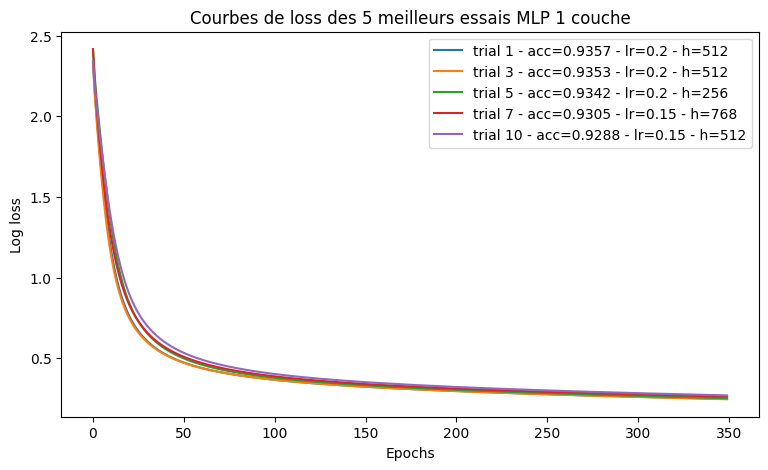

In [26]:
top5_mlp1 = sorted(
    results_mlp1_final_search,
    key=lambda r: r["valid_accuracy"],
    reverse=True
)[:5]

plt.figure(figsize=(9, 5))

for result in top5_mlp1:
    label = (
        f"trial {result['trial']} - "
        f"acc={result['valid_accuracy']:.4f} - "
        f"lr={result['params']['learning_rate']} - "
        f"h={result['params']['hidden_dim']}"
    )
    plt.plot(result["loss_history"], label=label)

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Courbes de loss des 5 meilleurs essais MLP 1 couche")
plt.legend()
plt.show()

### Analyse rapide de la random search du MLP à une couche cachée

Pour le MLP à une couche cachée, la random search ciblée montre que le learning rate a eu un impact important sur les performances. Les meilleurs résultats sont obtenus avec un learning rate de `0.2`, tandis que les valeurs plus faibles donnent des accuracies de validation plus basses avec le même nombre d’epochs. Cela suggère que, dans notre configuration, les learning rates plus faibles convergent plus lentement et auraient probablement besoin de davantage d’epochs pour atteindre des performances similaires.

Le meilleur modèle obtenu utilise `512` neurones cachés, un learning rate de `0.2` et `350` epochs, avec une validation accuracy de `0.9357`. On remarque aussi que le modèle avec `256` neurones et le même learning rate reste très proche, avec une validation accuracy de `0.9342`. Cela indique que le nombre de neurones a un effet plus limité que le learning rate dans nos essais, une fois que le modèle possède déjà une capacité suffisante.

# 3. Fine-Tunning du mlp2

## a) Premier essai/test

In [18]:
best_mlp2_test, results_mlp2_test = random_search_mlp_2_hidden(
    X_train_sub,
    Y_train_sub,
    X_valid,
    y_valid,
    train_mlp_2_hidden=train_mlp_2_hidden,
    predict_2_hidden=predict_2_hidden,
    accuracy=accuracy,
    n_trials=1,
    hidden_dim1_choices=(256,),
    hidden_dim2_choices=(128,),
    learning_rate_choices=(0.05,),
    epochs_choices=(10,),
    save_path="results_mlp2_test.pkl",
    seed=999
)


=== MLP 2 couches cachées - Essai 1/1 ===
hidden_dim1 = 256
hidden_dim2 = 128
learning_rate = 0.05
epochs = 10
Validation accuracy : 0.3479
Final loss : 2.125218684187055
Temps : 11.11 s

Meilleur résultat
Modèle : MLP 2 hidden
Validation accuracy : 0.3479
Final loss : 2.125218684187055
Temps : 11.11 s
Paramètres : {'hidden_dim1': 256, 'hidden_dim2': 128, 'learning_rate': 0.05, 'epochs': 10}


## b) Deuxieme essai (Plus long)

In [8]:
best_mlp2_night, results_mlp2_night = random_search_mlp_2_hidden(
    X_train_sub,
    Y_train_sub,
    X_valid,
    y_valid,
    train_mlp_2_hidden=train_mlp_2_hidden,
    predict_2_hidden=predict_2_hidden,
    accuracy=accuracy,
    n_trials=20,
    hidden_dim1_choices=(256, 512),
    hidden_dim2_choices=(128, 256),
    learning_rate_choices=(0.1, 0.05, 0.02, 0.01),
    epochs_choices=(350,),
    save_path="results_mlp2_night_reasonable.pkl",
    seed=909
)

save_results("all_mlp2_night_reasonable.pkl", {
    "best_mlp2": best_mlp2_night,
    "results_mlp2": results_mlp2_night
})


=== MLP 2 couches cachées - Essai 1/20 ===
hidden_dim1 = 256
hidden_dim2 = 256
learning_rate = 0.05
epochs = 350
Validation accuracy : 0.917
Final loss : 0.3182796069003501
Temps : 315.76 s

=== MLP 2 couches cachées - Essai 2/20 ===
hidden_dim1 = 256
hidden_dim2 = 256
learning_rate = 0.01
epochs = 350
Validation accuracy : 0.8629
Final loss : 0.6953597977822853
Temps : 290.47 s

=== MLP 2 couches cachées - Essai 3/20 ===
hidden_dim1 = 512
hidden_dim2 = 128
learning_rate = 0.01
epochs = 350
Validation accuracy : 0.8525
Final loss : 0.7342686828481275
Temps : 429.17 s

=== MLP 2 couches cachées - Essai 4/20 ===
hidden_dim1 = 256
hidden_dim2 = 256
learning_rate = 0.05
epochs = 350
Validation accuracy : 0.9167
Final loss : 0.3192927663305924
Temps : 280.12 s

=== MLP 2 couches cachées - Essai 5/20 ===
hidden_dim1 = 256
hidden_dim2 = 128
learning_rate = 0.1
epochs = 350
Validation accuracy : 0.9315
Final loss : 0.2553295700419685
Temps : 208.42 s

=== MLP 2 couches cachées - Essai 6/20 ==

In [9]:
df_mlp2 = results_to_dataframe(results_mlp2_night)
df_mlp2.head(10)

,model,trial,valid_accuracy,final_loss,time_sec,hidden_dim1,hidden_dim2,learning_rate,epochs
12,MLP 2 hidden,13,0.9382,0.236839,495.589038,512,256,0.10,350
11,MLP 2 hidden,12,0.9365,0.239862,482.591927,512,256,0.10,350
5,MLP 2 hidden,6,0.9349,0.243960,406.408535,512,128,0.10,350
18,MLP 2 hidden,19,0.9347,0.247868,332.018673,256,256,0.10,350
4,MLP 2 hidden,5,0.9315,0.255330,208.422046,256,128,0.10,350
8,MLP 2 hidden,9,0.9205,0.315109,393.886683,512,128,0.05,350
9,MLP 2 hidden,10,0.9187,0.321637,260.122221,256,128,0.05,350
10,MLP 2 hidden,11,0.9182,0.320396,268.734622,256,256,0.05,350
19,MLP 2 hidden,20,0.9173,0.325218,272.947761,256,128,0.05,350
0,MLP 2 hidden,1,0.9170,0.318280,315.756923,256,256,0.05,350


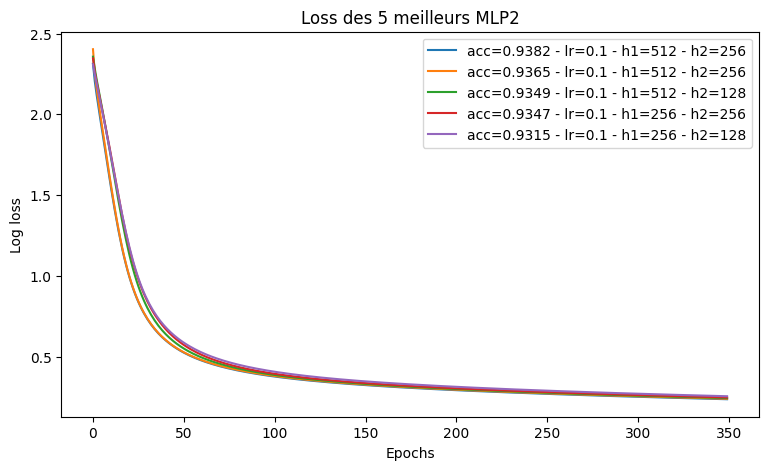

In [10]:
top5_mlp2 = sorted(results_mlp2_night, key=lambda r: r["valid_accuracy"], reverse=True)[:5]

plt.figure(figsize=(9, 5))

for result in top5_mlp2:
    label = (
        f"acc={result['valid_accuracy']:.4f} - "
        f"lr={result['params']['learning_rate']} - "
        f"h1={result['params']['hidden_dim1']} - "
        f"h2={result['params']['hidden_dim2']}"
    )
    plt.plot(result["loss_history"], label=label)

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss des 5 meilleurs MLP2")
plt.legend()
plt.show()

In [11]:
params = best_mlp2_night["best_parameters"]

y_pred_test_mlp2 = predict_2_hidden(
    X_test_flat,
    params["A1"],
    params["b1"],
    params["A2"],
    params["b2"],
    params["A3"],
    params["b3"]
)

acc_test_mlp2 = accuracy(y_test, y_pred_test_mlp2)

print("Accuracy test MLP 2 couches :", acc_test_mlp2)

Accuracy test MLP 2 couches : 0.934


### remarques
On remarque donc que le learning-rate semble etre le parametre qui influence le plus l'accuracy du modele. Le nombre de neurones par couche semble aussi influencer l'accuracy mais de maniere tres legere alors qu'elle fait augmenter assez fortement le temps de calcul. Il ne semble donc pas forcement necessaire d'augmenter encore le nombre de neurone par couche. De plus, on observe que l'on a pas specialement d'overfitting etant donne que l'accuracy obtenu sur le meilleur modele au cours du Random Search et tres proche de celle obtenu sur le dataset de test (0.9382 contre 0.934). On decide cependant de faire des essais supplementaires en augmentant le learning rate.

## c) Troisieme essai (en augmentant le learning rate)

In [12]:
best_mlp2_high_lr, results_mlp2_high_lr = random_search_mlp_2_hidden(
    X_train_sub,
    Y_train_sub,
    X_valid,
    y_valid,
    train_mlp_2_hidden=train_mlp_2_hidden,
    predict_2_hidden=predict_2_hidden,
    accuracy=accuracy,
    n_trials=6,
    hidden_dim1_choices=(512,),
    hidden_dim2_choices=(128, 256),
    learning_rate_choices=(0.1, 0.15, 0.2),
    epochs_choices=(350,),
    save_path="results_mlp2_high_lr.pkl",
    seed=1201
)


=== MLP 2 couches cachées - Essai 1/6 ===
hidden_dim1 = 512
hidden_dim2 = 128
learning_rate = 0.15
epochs = 350
Validation accuracy : 0.9456
Final loss : 0.20700612697703683
Temps : 539.71 s

=== MLP 2 couches cachées - Essai 2/6 ===
hidden_dim1 = 512
hidden_dim2 = 256
learning_rate = 0.1
epochs = 350
Validation accuracy : 0.9369
Final loss : 0.24001154923803478
Temps : 601.51 s

=== MLP 2 couches cachées - Essai 3/6 ===
hidden_dim1 = 512
hidden_dim2 = 128
learning_rate = 0.15
epochs = 350
Validation accuracy : 0.9484
Final loss : 0.19760686798781818
Temps : 509.96 s

=== MLP 2 couches cachées - Essai 4/6 ===
hidden_dim1 = 512
hidden_dim2 = 256
learning_rate = 0.15
epochs = 350
Validation accuracy : 0.9468
Final loss : 0.19990778985228752
Temps : 611.81 s

=== MLP 2 couches cachées - Essai 5/6 ===
hidden_dim1 = 512
hidden_dim2 = 128
learning_rate = 0.2
epochs = 350
Validation accuracy : 0.956
Final loss : 0.16855167029753063
Temps : 579.22 s

=== MLP 2 couches cachées - Essai 6/6 ===


In [17]:
df_mlp2_high = results_to_dataframe(results_mlp2_high_lr)
df_mlp2_high

,model,trial,valid_accuracy,final_loss,time_sec,hidden_dim1,hidden_dim2,learning_rate,epochs
4,MLP 2 hidden,5,0.9560,0.168552,579.217120,512,128,0.20,350
2,MLP 2 hidden,3,0.9484,0.197607,509.958184,512,128,0.15,350
3,MLP 2 hidden,4,0.9468,0.199908,611.809525,512,256,0.15,350
0,MLP 2 hidden,1,0.9456,0.207006,539.709157,512,128,0.15,350
5,MLP 2 hidden,6,0.9456,0.199757,713.243085,512,256,0.15,350
1,MLP 2 hidden,2,0.9369,0.240012,601.507431,512,256,0.10,350


In [13]:
params = best_mlp2_high_lr["best_parameters"]

y_pred_test_mlp2_high_lr = predict_2_hidden(
    X_test_flat,
    params["A1"],
    params["b1"],
    params["A2"],
    params["b2"],
    params["A3"],
    params["b3"]
)

acc_test_mlp2_high_lr = accuracy(y_test, y_pred_test_mlp2_high_lr)

print("Accuracy test MLP2 high lr :", acc_test_mlp2_high_lr)

Accuracy test MLP2 high lr : 0.9516


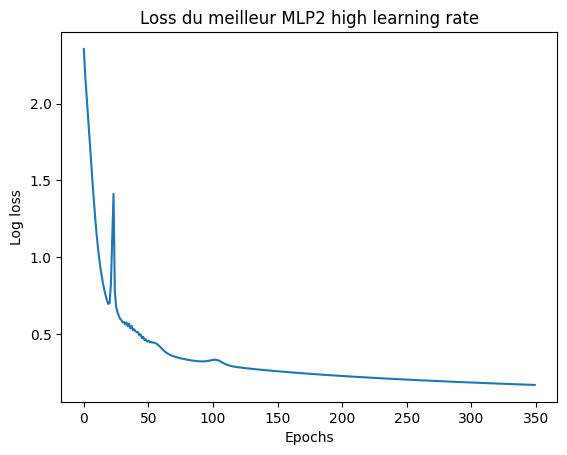

In [15]:
plt.plot(best_mlp2_high_lr["loss_history"])
plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Loss du meilleur MLP2 high learning rate")
plt.show()

On remarque

In [19]:
df_mlp2_night = results_to_dataframe(results_mlp2_night)
df_mlp2_high = results_to_dataframe(results_mlp2_high_lr)

df_compare_mlp2 = pd.concat([df_mlp2_night, df_mlp2_high], ignore_index=True)

df_compare_mlp2[
    [
        "model",
        "trial",
        "valid_accuracy",
        "final_loss",
        "time_sec",
        "hidden_dim1",
        "hidden_dim2",
        "learning_rate",
        "epochs"
    ]
].sort_values(by="valid_accuracy", ascending=False).head(15)

,model,trial,valid_accuracy,final_loss,time_sec,hidden_dim1,hidden_dim2,learning_rate,epochs
20,MLP 2 hidden,5,0.9560,0.168552,579.217120,512,128,0.20,350
21,MLP 2 hidden,3,0.9484,0.197607,509.958184,512,128,0.15,350
22,MLP 2 hidden,4,0.9468,0.199908,611.809525,512,256,0.15,350
23,MLP 2 hidden,1,0.9456,0.207006,539.709157,512,128,0.15,350
24,MLP 2 hidden,6,0.9456,0.199757,713.243085,512,256,0.15,350
0,MLP 2 hidden,13,0.9382,0.236839,495.589038,512,256,0.10,350
25,MLP 2 hidden,2,0.9369,0.240012,601.507431,512,256,0.10,350
1,MLP 2 hidden,12,0.9365,0.239862,482.591927,512,256,0.10,350
2,MLP 2 hidden,6,0.9349,0.243960,406.408535,512,128,0.10,350
3,MLP 2 hidden,19,0.9347,0.247868,332.018673,256,256,0.10,350


Après les premiers essais, on observe que les meilleurs résultats du MLP à deux couches cachées sont obtenus avec des learning rates élevés. Les modèles entraînés avec un learning rate de $0.1$ étaient déjà nettement meilleurs que ceux avec $0.05$, ce qui montre que le choix du pas d'apprentissage influence fortement la convergence du modèle. Nous avons donc réalisé une recherche plus ciblée autour de valeurs plus élevées, notamment $0.15$ et $0.2$.

Le meilleur résultat obtenu correspond à une architecture avec $512$ neurones dans la première couche cachée et $128$ neurones dans la deuxième. Cette structure en entonnoir paraît cohérente, car elle permet d'apprendre d'abord une représentation riche des pixels, puis de condenser progressivement l'information avant la couche de sortie. Les essais avec $256$ neurones dans la deuxième couche ne donnent pas systématiquement de meilleurs résultats, ce qui suggère que l'augmentation du nombre de neurones n'améliore pas forcément le modèle une fois qu'il possède déjà une capacité suffisante.

Cependant, la courbe de loss du meilleur modèle montre une légère instabilité au début de l'entraînement avec un learning rate de $0.2$. Le modèle finit par se stabiliser et converge correctement, mais cela indique que le pas d'apprentissage commence à devenir assez élevé. Nous ne jugeons donc pas nécessaire d'augmenter encore significativement le learning rate, car cela pourrait rendre l'entraînement plus instable.

Nous avons donc choisi de faire une dernière recherche plus ciblée autour de cette zone prometteuse, afin de confirmer le meilleur choix de learning rate et de taille pour la deuxième couche cachée.

# d) Essai final (avec lr autour de 2)

In [20]:
best_mlp2_final_search, results_mlp2_final_search = random_search_mlp_2_hidden(
    X_train_sub,
    Y_train_sub,
    X_valid,
    y_valid,
    train_mlp_2_hidden=train_mlp_2_hidden,
    predict_2_hidden=predict_2_hidden,
    accuracy=accuracy,
    n_trials=6,
    hidden_dim1_choices=(512,),
    hidden_dim2_choices=(128, 256),
    learning_rate_choices=(0.15, 0.18, 0.2),
    epochs_choices=(350,),
    save_path="results_mlp2_final_search.pkl",
    seed=1501
)

save_results("all_mlp2_final_search.pkl", {
    "best_mlp2": best_mlp2_final_search,
    "results_mlp2": results_mlp2_final_search
})


=== MLP 2 couches cachées - Essai 1/6 ===
hidden_dim1 = 512
hidden_dim2 = 256
learning_rate = 0.15
epochs = 350
Validation accuracy : 0.9477
Final loss : 0.19849694566537845
Temps : 704.54 s

=== MLP 2 couches cachées - Essai 2/6 ===
hidden_dim1 = 512
hidden_dim2 = 256
learning_rate = 0.2
epochs = 350
Validation accuracy : 0.9555
Final loss : 0.16541550074398131
Temps : 840.85 s

=== MLP 2 couches cachées - Essai 3/6 ===
hidden_dim1 = 512
hidden_dim2 = 128
learning_rate = 0.18
epochs = 350
Validation accuracy : 0.9525
Final loss : 0.1849793890116753
Temps : 707.93 s

=== MLP 2 couches cachées - Essai 4/6 ===
hidden_dim1 = 512
hidden_dim2 = 128
learning_rate = 0.18
epochs = 350
Validation accuracy : 0.9506
Final loss : 0.1844321368836425
Temps : 597.54 s

=== MLP 2 couches cachées - Essai 5/6 ===
hidden_dim1 = 512
hidden_dim2 = 256
learning_rate = 0.18
epochs = 350
Validation accuracy : 0.9529
Final loss : 0.1744584912356058
Temps : 714.53 s

=== MLP 2 couches cachées - Essai 6/6 ===
h

# 4. Synthese des resultats

In [37]:
comparison = pd.DataFrame([
    {
        "Modèle": "Linéaire",
        "Validation accuracy": best_linear_final_search["valid_accuracy"],
        "Test accuracy": acc_test_linear_final,
        "Final loss": best_linear_final_search["final_loss"],
        "Paramètres": best_linear_final_search["params"]
    },
    {
        "Modèle": "MLP 1 couche",
        "Validation accuracy": best_mlp1_final_search["valid_accuracy"],
        "Test accuracy": acc_test_mlp1_final,
        "Final loss": best_mlp1_final_search["final_loss"],
        "Paramètres": best_mlp1_final_search["params"]
    },
    {
        "Modèle": "MLP 2 couches",
        "Validation accuracy": best_mlp2_high_lr["valid_accuracy"],
        "Test accuracy": acc_test_mlp2_high_lr,
        "Final loss": best_mlp2_high_lr["final_loss"],
        "Paramètres": best_mlp2_high_lr["params"]
    }
])

comparison

,Modèle,Validation accuracy,Test accuracy,Final loss,Paramètres
0,Linéaire,0.9232,0.9215,0.286694,"{'learning_rate': 1.0, 'epochs': 500}"
1,MLP 1 couche,0.9357,0.9324,0.247481,"{'hidden_dim': 512, 'learning_rate': 0.2, 'epo..."
2,MLP 2 couches,0.9560,0.9516,0.168552,"{'hidden_dim1': 512, 'hidden_dim2': 128, 'lear..."


In [38]:
def top_n_by_model(results, n=3):
    df = results_to_dataframe(results)
    return (
        df.sort_values(by="valid_accuracy", ascending=False)
          .head(n)
    )

In [39]:
top3_linear = top_n_by_model(results_linear_final_search, n=3)
top3_mlp1 = top_n_by_model(results_mlp1_final_search, n=3)
top3_mlp2 = top_n_by_model(results_mlp2_high_lr, n=3)

top3_all = pd.concat([top3_linear, top3_mlp1, top3_mlp2], ignore_index=True)

top3_all

,model,trial,valid_accuracy,final_loss,time_sec,learning_rate,epochs,hidden_dim,hidden_dim1,hidden_dim2
0,Linear,7,0.9232,0.286694,43.445793,1.00,500,NaN,NaN,NaN
1,Linear,2,0.9230,0.286708,60.788902,1.00,500,NaN,NaN,NaN
2,Linear,1,0.9229,0.286726,83.677335,1.00,500,NaN,NaN,NaN
3,MLP 1 hidden,1,0.9357,0.247481,368.323895,0.20,350,512.0,NaN,NaN
4,MLP 1 hidden,3,0.9353,0.246128,390.052605,0.20,350,512.0,NaN,NaN
5,MLP 1 hidden,5,0.9342,0.252386,267.132307,0.20,350,256.0,NaN,NaN
6,MLP 2 hidden,5,0.9560,0.168552,579.217120,0.20,350,NaN,512.0,128.0
7,MLP 2 hidden,3,0.9484,0.197607,509.958184,0.15,350,NaN,512.0,128.0
8,MLP 2 hidden,4,0.9468,0.199908,611.809525,0.15,350,NaN,512.0,256.0


In [40]:
top3_all[
    [
        "model",
        "trial",
        "valid_accuracy",
        "final_loss",
        "time_sec",
        "learning_rate",
        "epochs",
        "hidden_dim",
        "hidden_dim1",
        "hidden_dim2"
    ]
]

,model,trial,valid_accuracy,final_loss,time_sec,learning_rate,epochs,hidden_dim,hidden_dim1,hidden_dim2
0,Linear,7,0.9232,0.286694,43.445793,1.00,500,NaN,NaN,NaN
1,Linear,2,0.9230,0.286708,60.788902,1.00,500,NaN,NaN,NaN
2,Linear,1,0.9229,0.286726,83.677335,1.00,500,NaN,NaN,NaN
3,MLP 1 hidden,1,0.9357,0.247481,368.323895,0.20,350,512.0,NaN,NaN
4,MLP 1 hidden,3,0.9353,0.246128,390.052605,0.20,350,512.0,NaN,NaN
5,MLP 1 hidden,5,0.9342,0.252386,267.132307,0.20,350,256.0,NaN,NaN
6,MLP 2 hidden,5,0.9560,0.168552,579.217120,0.20,350,NaN,512.0,128.0
7,MLP 2 hidden,3,0.9484,0.197607,509.958184,0.15,350,NaN,512.0,128.0
8,MLP 2 hidden,4,0.9468,0.199908,611.809525,0.15,350,NaN,512.0,256.0


In [41]:
def plot_top_losses(results, title, top_n=3):
    top_results = sorted(
        results,
        key=lambda r: r["valid_accuracy"],
        reverse=True
    )[:top_n]

    plt.figure(figsize=(8, 5))

    for result in top_results:
        label = f"acc={result['valid_accuracy']:.4f}, lr={result['params']['learning_rate']}"

        if "hidden_dim" in result["params"]:
            label += f", h={result['params']['hidden_dim']}"
        if "hidden_dim1" in result["params"]:
            label += f", h1={result['params']['hidden_dim1']}, h2={result['params']['hidden_dim2']}"

        plt.plot(result["loss_history"], label=label)

    plt.xlabel("Epochs")
    plt.ylabel("Log loss")
    plt.title(title)
    plt.legend()
    plt.show()

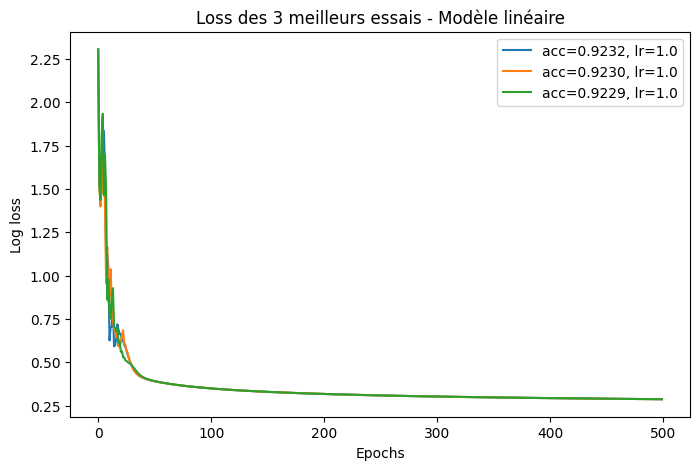

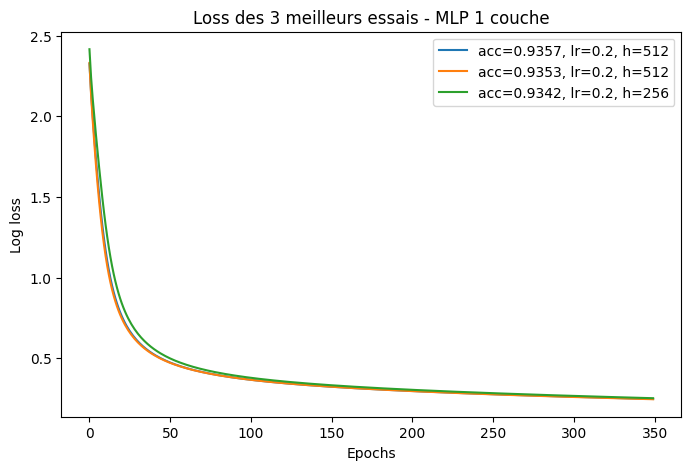

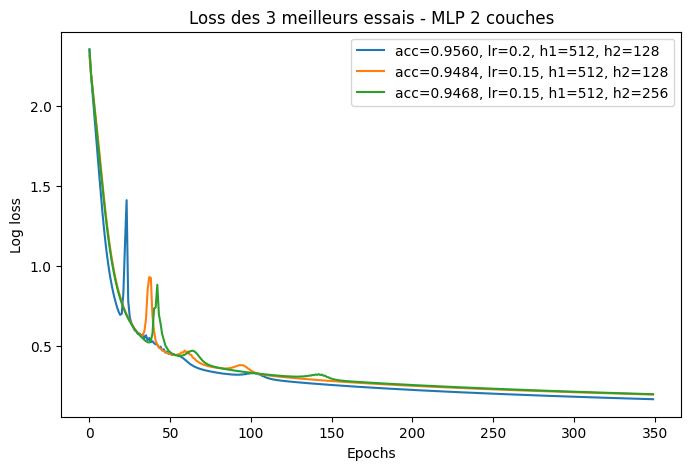

In [42]:
plot_top_losses(results_linear_final_search, "Loss des 3 meilleurs essais - Modèle linéaire")
plot_top_losses(results_mlp1_final_search, "Loss des 3 meilleurs essais - MLP 1 couche")
plot_top_losses(results_mlp2_high_lr, "Loss des 3 meilleurs essais - MLP 2 couches")

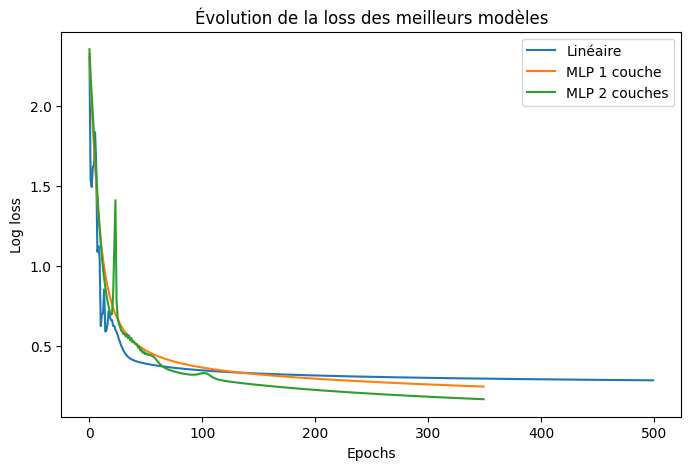

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(best_linear_final_search["loss_history"], label="Linéaire")
plt.plot(best_mlp1_final_search["loss_history"], label="MLP 1 couche")
plt.plot(best_mlp2_high_lr["loss_history"], label="MLP 2 couches")

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Évolution de la loss des meilleurs modèles")
plt.legend()
plt.show()

In [44]:
comparison = pd.DataFrame([
    {
        "Modèle": "Linéaire",
        "Validation accuracy": best_linear_final_search["valid_accuracy"],
        "Test accuracy": acc_test_linear_final,
    },
    {
        "Modèle": "MLP 1 couche",
        "Validation accuracy": best_mlp1_final_search["valid_accuracy"],
        "Test accuracy": acc_test_mlp1_final,
    },
    {
        "Modèle": "MLP 2 couches",
        "Validation accuracy": best_mlp2_high_lr["valid_accuracy"],
        "Test accuracy": acc_test_mlp2_high_lr,
    }
])

comparison

,Modèle,Validation accuracy,Test accuracy
0,Linéaire,0.9232,0.9215
1,MLP 1 couche,0.9357,0.9324
2,MLP 2 couches,0.9560,0.9516


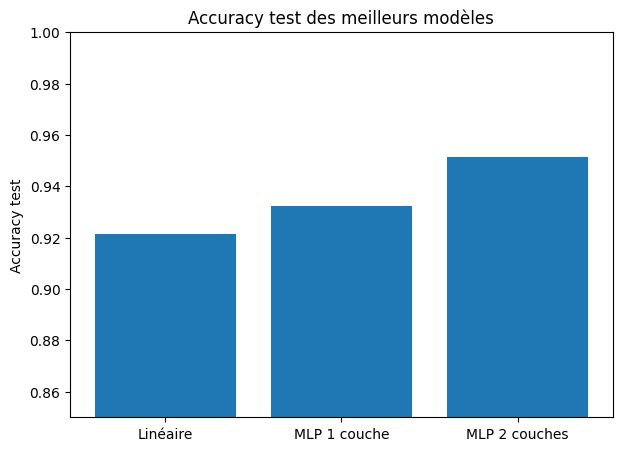

In [45]:
plt.figure(figsize=(7, 5))

plt.bar(comparison["Modèle"], comparison["Test accuracy"])

plt.ylabel("Accuracy test")
plt.title("Accuracy test des meilleurs modèles")
plt.ylim(0.85, 1.0)

plt.show()

## 5. Bilan des meilleurs resultats

In [47]:
[name for name in globals().keys() if "results_mlp" in name or "results_linear" in name]

['results_mlp2_night',
 'results_mlp2_high_lr',
 'results_mlp2_final_search',
 'results_mlp1_final_search',
 'results_linear_final_search']

In [48]:
all_linear_results = results_linear_final_search

all_mlp1_results = results_mlp1_final_search

all_mlp2_results = (
    results_mlp2_night
    + results_mlp2_high_lr
    + results_mlp2_final_search
)

In [49]:
best_linear = max(all_linear_results, key=lambda r: r["valid_accuracy"])
best_mlp1 = max(all_mlp1_results, key=lambda r: r["valid_accuracy"])
best_mlp2 = max(all_mlp2_results, key=lambda r: r["valid_accuracy"])

print("Best linear :", best_linear["valid_accuracy"], best_linear["params"])
print("Best MLP1 :", best_mlp1["valid_accuracy"], best_mlp1["params"])
print("Best MLP2 :", best_mlp2["valid_accuracy"], best_mlp2["params"])

Best linear : 0.9232 {'learning_rate': 1.0, 'epochs': 500}
Best MLP1 : 0.9357 {'hidden_dim': 512, 'learning_rate': 0.2, 'epochs': 350}
Best MLP2 : 0.956 {'hidden_dim1': 512, 'hidden_dim2': 128, 'learning_rate': 0.2, 'epochs': 350}


In [50]:
# Modèle linéaire
params = best_linear["best_parameters"]

y_pred_test_linear = predict(
    X_test_flat,
    params["A"],
    params["b"]
)

acc_test_linear = accuracy(y_test, y_pred_test_linear)

print("Accuracy test linéaire :", acc_test_linear)

Accuracy test linéaire : 0.9215


In [51]:
# MLP 1 couche
params = best_mlp1["best_parameters"]

y_pred_test_mlp1 = predict_1_hidden(
    X_test_flat,
    params["A1"],
    params["b1"],
    params["A2"],
    params["b2"]
)

acc_test_mlp1 = accuracy(y_test, y_pred_test_mlp1)

print("Accuracy test MLP1 :", acc_test_mlp1)

Accuracy test MLP1 : 0.9324


In [52]:
# MLP 2 couches
params = best_mlp2["best_parameters"]

y_pred_test_mlp2 = predict_2_hidden(
    X_test_flat,
    params["A1"],
    params["b1"],
    params["A2"],
    params["b2"],
    params["A3"],
    params["b3"]
)

acc_test_mlp2 = accuracy(y_test, y_pred_test_mlp2)

print("Accuracy test MLP2 :", acc_test_mlp2)

Accuracy test MLP2 : 0.9516


In [53]:
comparison = pd.DataFrame([
    {
        "Modèle": "Linéaire",
        "Validation accuracy": best_linear["valid_accuracy"],
        "Test accuracy": acc_test_linear,
        "Final loss": best_linear["final_loss"],
        "Temps entraînement (s)": best_linear["time_sec"],
        "Paramètres": best_linear["params"]
    },
    {
        "Modèle": "MLP 1 couche",
        "Validation accuracy": best_mlp1["valid_accuracy"],
        "Test accuracy": acc_test_mlp1,
        "Final loss": best_mlp1["final_loss"],
        "Temps entraînement (s)": best_mlp1["time_sec"],
        "Paramètres": best_mlp1["params"]
    },
    {
        "Modèle": "MLP 2 couches",
        "Validation accuracy": best_mlp2["valid_accuracy"],
        "Test accuracy": acc_test_mlp2,
        "Final loss": best_mlp2["final_loss"],
        "Temps entraînement (s)": best_mlp2["time_sec"],
        "Paramètres": best_mlp2["params"]
    }
])

comparison

,Modèle,Validation accuracy,Test accuracy,Final loss,Temps entraînement (s),Paramètres
0,Linéaire,0.9232,0.9215,0.286694,43.445793,"{'learning_rate': 1.0, 'epochs': 500}"
1,MLP 1 couche,0.9357,0.9324,0.247481,368.323895,"{'hidden_dim': 512, 'learning_rate': 0.2, 'epo..."
2,MLP 2 couches,0.9560,0.9516,0.168552,579.217120,"{'hidden_dim1': 512, 'hidden_dim2': 128, 'lear..."


In [55]:
df_linear_all = results_to_dataframe(all_linear_results)
df_mlp1_all = results_to_dataframe(all_mlp1_results)
df_mlp2_all = results_to_dataframe(all_mlp2_results)

In [56]:
df_linear_all.head(5)


,model,trial,valid_accuracy,final_loss,time_sec,learning_rate,epochs
6,Linear,7,0.9232,0.286694,43.445793,1.0,500
1,Linear,2,0.9230,0.286708,60.788902,1.0,500
0,Linear,1,0.9229,0.286726,83.677335,1.0,500
4,Linear,5,0.9190,0.308821,61.364449,0.5,500
7,Linear,8,0.9182,0.308819,62.652611,0.5,500


In [57]:
df_mlp1_all.head(5)

,model,trial,valid_accuracy,final_loss,time_sec,hidden_dim,learning_rate,epochs
0,MLP 1 hidden,1,0.9357,0.247481,368.323895,512,0.20,350
2,MLP 1 hidden,3,0.9353,0.246128,390.052605,512,0.20,350
4,MLP 1 hidden,5,0.9342,0.252386,267.132307,256,0.20,350
6,MLP 1 hidden,7,0.9305,0.262253,689.857121,768,0.15,350
9,MLP 1 hidden,10,0.9288,0.269923,476.769438,512,0.15,350


In [58]:
df_mlp2_all.head(5)

,model,trial,valid_accuracy,final_loss,time_sec,hidden_dim1,hidden_dim2,learning_rate,epochs
24,MLP 2 hidden,5,0.9560,0.168552,579.217120,512,128,0.20,350
27,MLP 2 hidden,2,0.9555,0.165416,840.854966,512,256,0.20,350
30,MLP 2 hidden,5,0.9529,0.174458,714.525621,512,256,0.18,350
28,MLP 2 hidden,3,0.9525,0.184979,707.925623,512,128,0.18,350
29,MLP 2 hidden,4,0.9506,0.184432,597.541377,512,128,0.18,350


In [59]:
# =========================
# Top 3 des meilleurs essais par modèle
# =========================

top3_linear = df_linear_all.head(3).copy()
top3_mlp1 = df_mlp1_all.head(3).copy()
top3_mlp2 = df_mlp2_all.head(3).copy()

# On regroupe tout dans un seul tableau
top3_all = pd.concat([top3_linear, top3_mlp1, top3_mlp2], ignore_index=True)

# Colonnes utiles à afficher
columns_to_show = [
    "model",
    "trial",
    "valid_accuracy",
    "final_loss",
    "time_sec",
    "learning_rate",
    "epochs",
    "hidden_dim",
    "hidden_dim1",
    "hidden_dim2"
]

top3_all[columns_to_show]

,model,trial,valid_accuracy,final_loss,time_sec,learning_rate,epochs,hidden_dim,hidden_dim1,hidden_dim2
0,Linear,7,0.9232,0.286694,43.445793,1.00,500,NaN,NaN,NaN
1,Linear,2,0.9230,0.286708,60.788902,1.00,500,NaN,NaN,NaN
2,Linear,1,0.9229,0.286726,83.677335,1.00,500,NaN,NaN,NaN
3,MLP 1 hidden,1,0.9357,0.247481,368.323895,0.20,350,512.0,NaN,NaN
4,MLP 1 hidden,3,0.9353,0.246128,390.052605,0.20,350,512.0,NaN,NaN
5,MLP 1 hidden,5,0.9342,0.252386,267.132307,0.20,350,256.0,NaN,NaN
6,MLP 2 hidden,5,0.9560,0.168552,579.217120,0.20,350,NaN,512.0,128.0
7,MLP 2 hidden,2,0.9555,0.165416,840.854966,0.20,350,NaN,512.0,256.0
8,MLP 2 hidden,5,0.9529,0.174458,714.525621,0.18,350,NaN,512.0,256.0


In [60]:
# =========================
# Fonction pour calculer l'accuracy test d'un résultat
# =========================

def compute_test_accuracy_from_result(result):
    params = result["best_parameters"]
    model_name = result["model"]

    if model_name == "Linear":
        y_pred_test = predict(
            X_test_flat,
            params["A"],
            params["b"]
        )

    elif model_name == "MLP 1 hidden":
        y_pred_test = predict_1_hidden(
            X_test_flat,
            params["A1"],
            params["b1"],
            params["A2"],
            params["b2"]
        )

    elif model_name == "MLP 2 hidden":
        y_pred_test = predict_2_hidden(
            X_test_flat,
            params["A1"],
            params["b1"],
            params["A2"],
            params["b2"],
            params["A3"],
            params["b3"]
        )

    else:
        raise ValueError(f"Modèle inconnu : {model_name}")

    return accuracy(y_test, y_pred_test)


# =========================
# Tableau propre : top 3 de chaque modèle + test accuracy
# =========================

def top3_clean_table_with_test(results, model_name):
    top3_results = sorted(
        results,
        key=lambda r: r["valid_accuracy"],
        reverse=True
    )[:3]

    rows = []

    for result in top3_results:
        params = result["params"]
        test_acc = compute_test_accuracy_from_result(result)

        rows.append({
            "Modèle": model_name,
            "Trial": result["trial"],
            "Validation accuracy": result["valid_accuracy"],
            "Test accuracy": test_acc,
            "Final loss": result["final_loss"],
            "Temps (s)": result["time_sec"],
            "Paramètres": params
        })

    return pd.DataFrame(rows)


top3_table_with_test = pd.concat([
    top3_clean_table_with_test(all_linear_results, "Linéaire"),
    top3_clean_table_with_test(all_mlp1_results, "MLP 1 couche"),
    top3_clean_table_with_test(all_mlp2_results, "MLP 2 couches")
], ignore_index=True)

top3_table_with_test

,Modèle,Trial,Validation accuracy,Test accuracy,Final loss,Temps (s),Paramètres
0,Linéaire,7,0.9232,0.9215,0.286694,43.445793,"{'learning_rate': 1.0, 'epochs': 500}"
1,Linéaire,2,0.9230,0.9218,0.286708,60.788902,"{'learning_rate': 1.0, 'epochs': 500}"
2,Linéaire,1,0.9229,0.9215,0.286726,83.677335,"{'learning_rate': 1.0, 'epochs': 500}"
3,MLP 1 couche,1,0.9357,0.9324,0.247481,368.323895,"{'hidden_dim': 512, 'learning_rate': 0.2, 'epo..."
4,MLP 1 couche,3,0.9353,0.9336,0.246128,390.052605,"{'hidden_dim': 512, 'learning_rate': 0.2, 'epo..."
5,MLP 1 couche,5,0.9342,0.9314,0.252386,267.132307,"{'hidden_dim': 256, 'learning_rate': 0.2, 'epo..."
6,MLP 2 couches,5,0.9560,0.9516,0.168552,579.217120,"{'hidden_dim1': 512, 'hidden_dim2': 128, 'lear..."
7,MLP 2 couches,2,0.9555,0.9504,0.165416,840.854966,"{'hidden_dim1': 512, 'hidden_dim2': 256, 'lear..."
8,MLP 2 couches,5,0.9529,0.9485,0.174458,714.525621,"{'hidden_dim1': 512, 'hidden_dim2': 256, 'lear..."


In [61]:
# =========================
# Fonction pour calculer l'accuracy test d'un résultat
# =========================

def compute_test_accuracy_from_result(result):
    params = result["best_parameters"]
    model_name = result["model"]

    if model_name == "Linear":
        y_pred_test = predict(
            X_test_flat,
            params["A"],
            params["b"]
        )

    elif model_name == "MLP 1 hidden":
        y_pred_test = predict_1_hidden(
            X_test_flat,
            params["A1"],
            params["b1"],
            params["A2"],
            params["b2"]
        )

    elif model_name == "MLP 2 hidden":
        y_pred_test = predict_2_hidden(
            X_test_flat,
            params["A1"],
            params["b1"],
            params["A2"],
            params["b2"],
            params["A3"],
            params["b3"]
        )

    else:
        raise ValueError(f"Modèle inconnu : {model_name}")

    return accuracy(y_test, y_pred_test)


# =========================
# Tableau top 3 de chaque modèle avec paramètres en colonnes
# =========================

def top3_table_with_clean_params(results, model_display_name):
    top3_results = sorted(
        results,
        key=lambda r: r["valid_accuracy"],
        reverse=True
    )[:3]

    rows = []

    for result in top3_results:
        params = result["params"]
        test_acc = compute_test_accuracy_from_result(result)

        rows.append({
            "Modèle": model_display_name,
            "Trial": result["trial"],
            "Validation accuracy": result["valid_accuracy"],
            "Test accuracy": test_acc,
            "Final loss": result["final_loss"],
            "Temps (s)": result["time_sec"],
            "Learning rate": params.get("learning_rate", None),
            "Epochs": params.get("epochs", None),
            "Hidden dim": params.get("hidden_dim", None),
            "Hidden dim 1": params.get("hidden_dim1", None),
            "Hidden dim 2": params.get("hidden_dim2", None),
        })

    return pd.DataFrame(rows)


top3_table_clean = pd.concat([
    top3_table_with_clean_params(all_linear_results, "Linéaire"),
    top3_table_with_clean_params(all_mlp1_results, "MLP 1 couche"),
    top3_table_with_clean_params(all_mlp2_results, "MLP 2 couches")
], ignore_index=True)

# Réorganisation des colonnes
top3_table_clean = top3_table_clean[
    [
        "Modèle",
        "Trial",
        "Validation accuracy",
        "Test accuracy",
        "Final loss",
        "Temps (s)",
        "Learning rate",
        "Epochs",
        "Hidden dim",
        "Hidden dim 1",
        "Hidden dim 2",
    ]
]

top3_table_clean

,Modèle,Trial,Validation accuracy,Test accuracy,Final loss,Temps (s),Learning rate,Epochs,Hidden dim,Hidden dim 1,Hidden dim 2
0,Linéaire,7,0.9232,0.9215,0.286694,43.445793,1.00,500,None,None,None
1,Linéaire,2,0.9230,0.9218,0.286708,60.788902,1.00,500,None,None,None
2,Linéaire,1,0.9229,0.9215,0.286726,83.677335,1.00,500,None,None,None
3,MLP 1 couche,1,0.9357,0.9324,0.247481,368.323895,0.20,350,512,None,None
4,MLP 1 couche,3,0.9353,0.9336,0.246128,390.052605,0.20,350,512,None,None
5,MLP 1 couche,5,0.9342,0.9314,0.252386,267.132307,0.20,350,256,None,None
6,MLP 2 couches,5,0.9560,0.9516,0.168552,579.217120,0.20,350,None,512,128
7,MLP 2 couches,2,0.9555,0.9504,0.165416,840.854966,0.20,350,None,512,256
8,MLP 2 couches,5,0.9529,0.9485,0.174458,714.525621,0.18,350,None,512,256


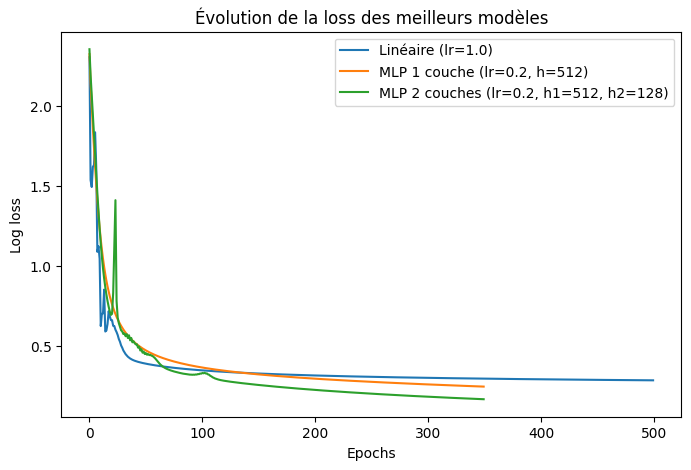

In [62]:
plt.figure(figsize=(8, 5))

plt.plot(
    best_linear["loss_history"],
    label=f"Linéaire (lr={best_linear['params']['learning_rate']})"
)

plt.plot(
    best_mlp1["loss_history"],
    label=f"MLP 1 couche (lr={best_mlp1['params']['learning_rate']}, h={best_mlp1['params']['hidden_dim']})"
)

plt.plot(
    best_mlp2["loss_history"],
    label=f"MLP 2 couches (lr={best_mlp2['params']['learning_rate']}, h1={best_mlp2['params']['hidden_dim1']}, h2={best_mlp2['params']['hidden_dim2']})"
)

plt.xlabel("Epochs")
plt.ylabel("Log loss")
plt.title("Évolution de la loss des meilleurs modèles")
plt.legend()
plt.show()

In [65]:
# =========================
# Fonctions pour calculer les accuracies train/test d'un résultat
# =========================

def compute_train_accuracy_from_result(result):
    params = result["best_parameters"]
    model_name = result["model"]

    if model_name == "Linear":
        y_pred_train = predict(
            X_train_sub,
            params["A"],
            params["b"]
        )

    elif model_name == "MLP 1 hidden":
        y_pred_train = predict_1_hidden(
            X_train_sub,
            params["A1"],
            params["b1"],
            params["A2"],
            params["b2"]
        )

    elif model_name == "MLP 2 hidden":
        y_pred_train = predict_2_hidden(
            X_train_sub,
            params["A1"],
            params["b1"],
            params["A2"],
            params["b2"],
            params["A3"],
            params["b3"]
        )

    else:
        raise ValueError(f"Modèle inconnu : {model_name}")

    return accuracy(y_train_sub, y_pred_train)


def compute_test_accuracy_from_result(result):
    params = result["best_parameters"]
    model_name = result["model"]

    if model_name == "Linear":
        y_pred_test = predict(
            X_test_flat,
            params["A"],
            params["b"]
        )

    elif model_name == "MLP 1 hidden":
        y_pred_test = predict_1_hidden(
            X_test_flat,
            params["A1"],
            params["b1"],
            params["A2"],
            params["b2"]
        )

    elif model_name == "MLP 2 hidden":
        y_pred_test = predict_2_hidden(
            X_test_flat,
            params["A1"],
            params["b1"],
            params["A2"],
            params["b2"],
            params["A3"],
            params["b3"]
        )

    else:
        raise ValueError(f"Modèle inconnu : {model_name}")

    return accuracy(y_test, y_pred_test)


# =========================
# Tableau top 3 de chaque modèle avec paramètres en colonnes
# =========================

def top3_table_with_clean_params(results, model_display_name):
    top3_results = sorted(
        results,
        key=lambda r: r["valid_accuracy"],
        reverse=True
    )[:3]

    rows = []

    for result in top3_results:
        params = result["params"]
        train_acc = compute_train_accuracy_from_result(result)
        test_acc = compute_test_accuracy_from_result(result)

        rows.append({
            "Modèle": model_display_name,
            "Trial": result["trial"],
            "Training accuracy": train_acc,
            "Validation accuracy": result["valid_accuracy"],
            "Test accuracy": test_acc,
            "Final loss": result["final_loss"],
            "Temps (s)": result["time_sec"],
            "Learning rate": params.get("learning_rate", None),
            "Epochs": params.get("epochs", None),
            "Hidden dim": params.get("hidden_dim", None),
            "Hidden dim 1": params.get("hidden_dim1", None),
            "Hidden dim 2": params.get("hidden_dim2", None),
        })

    return pd.DataFrame(rows)


top3_table_clean = pd.concat([
    top3_table_with_clean_params(all_linear_results, "Linéaire"),
    top3_table_with_clean_params(all_mlp1_results, "MLP 1 couche"),
    top3_table_with_clean_params(all_mlp2_results, "MLP 2 couches")
], ignore_index=True)


# =========================
# Réorganisation + arrondi des colonnes
# =========================

top3_table_clean = top3_table_clean[
    [
        "Modèle",
        "Trial",
        "Training accuracy",
        "Validation accuracy",
        "Test accuracy",
        "Final loss",
        "Temps (s)",
        "Learning rate",
        "Epochs",
        "Hidden dim",
        "Hidden dim 1",
        "Hidden dim 2",
    ]
]

top3_table_clean_rounded = top3_table_clean.copy()

top3_table_clean_rounded["Training accuracy"] = top3_table_clean_rounded["Training accuracy"].round(4)
top3_table_clean_rounded["Validation accuracy"] = top3_table_clean_rounded["Validation accuracy"].round(4)
top3_table_clean_rounded["Test accuracy"] = top3_table_clean_rounded["Test accuracy"].round(4)
top3_table_clean_rounded["Final loss"] = top3_table_clean_rounded["Final loss"].round(4)
top3_table_clean_rounded["Temps (s)"] = top3_table_clean_rounded["Temps (s)"].round(2)
top3_table_clean_rounded["Learning rate"] = top3_table_clean_rounded["Learning rate"].round(3)

top3_table_clean_rounded



,Modèle,Trial,Training accuracy,Validation accuracy,Test accuracy,Final loss,Temps (s),Learning rate,Epochs,Hidden dim,Hidden dim 1,Hidden dim 2
0,Linéaire,7,0.9205,0.9232,0.9215,0.2867,43.45,1.00,500,None,None,None
1,Linéaire,2,0.9204,0.9230,0.9218,0.2867,60.79,1.00,500,None,None,None
2,Linéaire,1,0.9205,0.9229,0.9215,0.2867,83.68,1.00,500,None,None,None
3,MLP 1 couche,1,0.9313,0.9357,0.9324,0.2475,368.32,0.20,350,512,None,None
4,MLP 1 couche,3,0.9315,0.9353,0.9336,0.2461,390.05,0.20,350,512,None,None
5,MLP 1 couche,5,0.9300,0.9342,0.9314,0.2524,267.13,0.20,350,256,None,None
6,MLP 2 couches,5,0.9520,0.9560,0.9516,0.1686,579.22,0.20,350,None,512,128
7,MLP 2 couches,2,0.9534,0.9555,0.9504,0.1654,840.85,0.20,350,None,512,256
8,MLP 2 couches,5,0.9507,0.9529,0.9485,0.1745,714.53,0.18,350,None,512,256


# Analyse des erreurs

In [75]:
# =========================
# Matrice de confusion du meilleur modèle MLP2
# =========================

# Récupération du meilleur modèle MLP2
all_mlp2_results = (
    results_mlp2_night
    + results_mlp2_high_lr
    + results_mlp2_final_search
)

best_mlp2 = max(all_mlp2_results, key=lambda r: r["valid_accuracy"])

params = best_mlp2["best_parameters"]

# Prédictions sur le test set
y_pred_best = predict_2_hidden(
    X_test_flat,
    params["A1"],
    params["b1"],
    params["A2"],
    params["b2"],
    params["A3"],
    params["b3"]
)

acc_best = accuracy(y_test, y_pred_best)

print("Accuracy test du meilleur MLP2 :", acc_best)
print("Paramètres :", best_mlp2["params"])


# =========================
# Calcul de la matrice de confusion avec NumPy
# =========================

num_classes = 10
cm = np.zeros((num_classes, num_classes), dtype=int)

for true_label, pred_label in zip(y_test, y_pred_best):
    cm[true_label, pred_label] += 1

print("Accuracy depuis la matrice :", np.trace(cm) / np.sum(cm))

Accuracy test du meilleur MLP2 : 0.9516
Paramètres : {'hidden_dim1': 512, 'hidden_dim2': 128, 'learning_rate': 0.2, 'epochs': 350}
Accuracy depuis la matrice : 0.9516


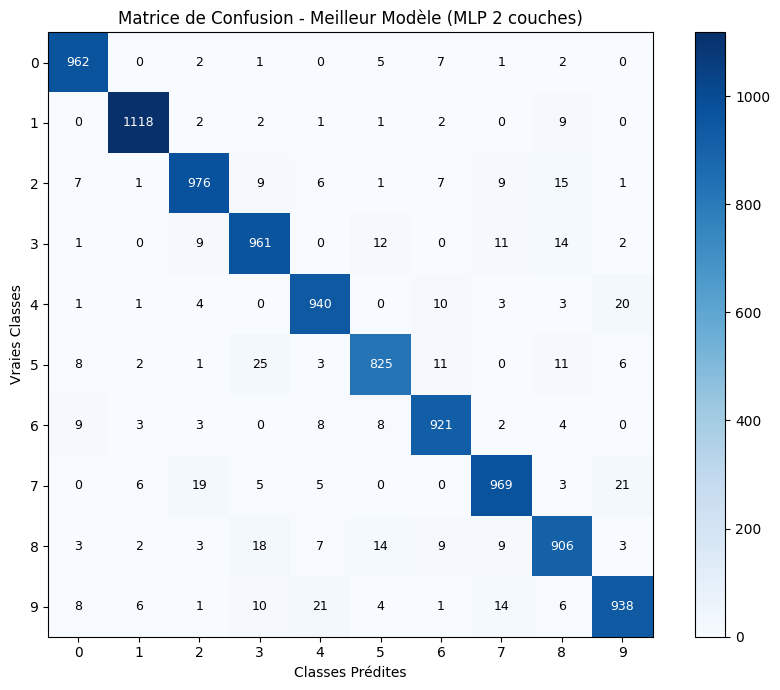

In [76]:
# =========================
# Affichage de la matrice de confusion
# =========================

plt.figure(figsize=(9, 7))

plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Matrice de Confusion - Meilleur Modèle (MLP 2 couches)")
plt.colorbar()

classes = np.arange(10)

plt.xticks(classes, classes)
plt.yticks(classes, classes)

plt.xlabel("Classes Prédites")
plt.ylabel("Vraies Classes")

# Seuil pour choisir la couleur du texte
threshold = cm.max() / 2

for i in range(num_classes):
    for j in range(num_classes):
        color = "white" if cm[i, j] > threshold else "black"
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color=color,
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [77]:
# =========================
# Principales confusions
# =========================

confusions = []

for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > 0:
            confusions.append((i, j, cm[i, j]))

confusions = sorted(confusions, key=lambda x: x[2], reverse=True)

print("Principales confusions :")
for true_label, pred_label, count in confusions[:10]:
    print(f"Vrai {true_label} prédit {pred_label} : {count} erreurs")

Principales confusions :
Vrai 5 prédit 3 : 25 erreurs
Vrai 7 prédit 9 : 21 erreurs
Vrai 9 prédit 4 : 21 erreurs
Vrai 4 prédit 9 : 20 erreurs
Vrai 7 prédit 2 : 19 erreurs
Vrai 8 prédit 3 : 18 erreurs
Vrai 2 prédit 8 : 15 erreurs
Vrai 3 prédit 8 : 14 erreurs
Vrai 8 prédit 5 : 14 erreurs
Vrai 9 prédit 7 : 14 erreurs


Accuracy test du meilleur MLP2 : 0.9516
Shape des activations Z2 : (10000, 128)
Shape après ACP : (10000, 2)


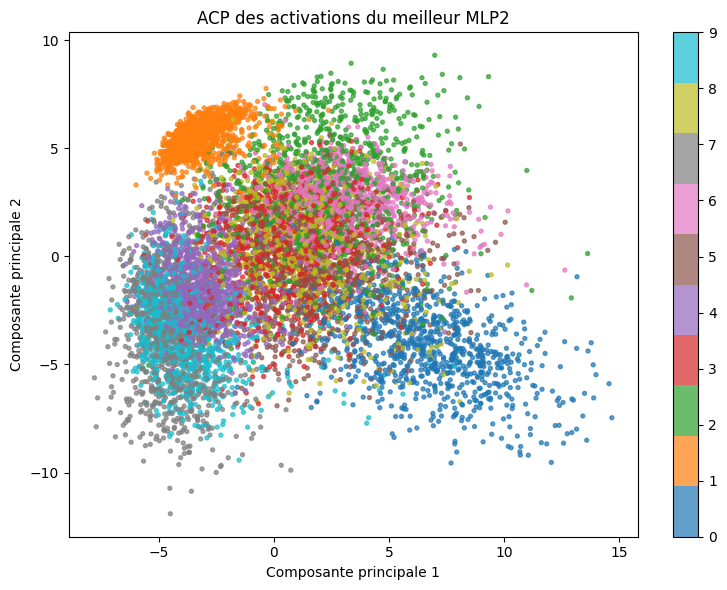

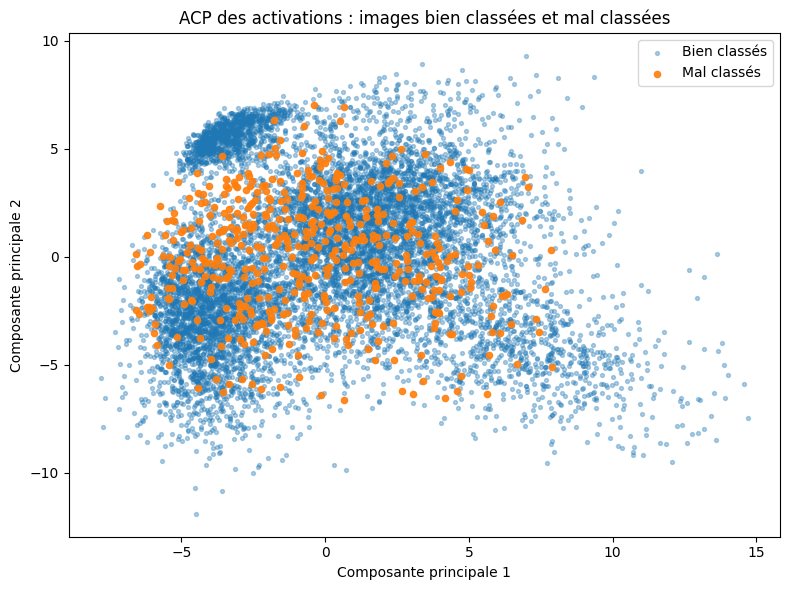

In [78]:
# =========================
# ACP des activations du meilleur MLP2
# =========================

from mlp_model import forward_2_hidden
import numpy as np
import matplotlib.pyplot as plt

# 1) Récupérer les paramètres du meilleur modèle
params = best_mlp2["best_parameters"]

# 2) Prédictions du meilleur modèle sur le test set
y_pred_best = predict_2_hidden(
    X_test_flat,
    params["A1"],
    params["b1"],
    params["A2"],
    params["b2"],
    params["A3"],
    params["b3"]
)

acc_best = accuracy(y_test, y_pred_best)
print("Accuracy test du meilleur MLP2 :", acc_best)

# 3) Forward pass pour récupérer les activations de la dernière couche cachée
probas_test, cache_test = forward_2_hidden(
    X_test_flat,
    params["A1"],
    params["b1"],
    params["A2"],
    params["b2"],
    params["A3"],
    params["b3"]
)

Z2_test = cache_test["Z2"]
print("Shape des activations Z2 :", Z2_test.shape)

# 4) ACP/PCA en 2 dimensions avec NumPy
Z2_centered = Z2_test - np.mean(Z2_test, axis=0)

U, S, Vt = np.linalg.svd(Z2_centered, full_matrices=False)

Z2_pca_2d = Z2_centered @ Vt[:2].T
print("Shape après ACP :", Z2_pca_2d.shape)

# 5) Graphique 1 : ACP colorée par vraie classe
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    Z2_pca_2d[:, 0],
    Z2_pca_2d[:, 1],
    c=y_test,
    cmap="tab10",
    s=8,
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(10))
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("ACP des activations du meilleur MLP2")
plt.tight_layout()
plt.show()

# 6) Graphique 2 : ACP avec erreurs mises en évidence
errors = (y_pred_best != y_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    Z2_pca_2d[~errors, 0],
    Z2_pca_2d[~errors, 1],
    s=8,
    alpha=0.35,
    label="Bien classés"
)

plt.scatter(
    Z2_pca_2d[errors, 0],
    Z2_pca_2d[errors, 1],
    s=20,
    alpha=0.9,
    label="Mal classés"
)

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("ACP des activations : images bien classées et mal classées")
plt.legend()
plt.tight_layout()
plt.show()

Principales confusions :
Vrai 5 prédit 3 : 25 erreurs
Vrai 7 prédit 9 : 21 erreurs
Vrai 9 prédit 4 : 21 erreurs
Vrai 4 prédit 9 : 20 erreurs
Vrai 7 prédit 2 : 19 erreurs
Vrai 8 prédit 3 : 18 erreurs
Vrai 2 prédit 8 : 15 erreurs
Vrai 3 prédit 8 : 14 erreurs
Vrai 8 prédit 5 : 14 erreurs
Vrai 9 prédit 7 : 14 erreurs


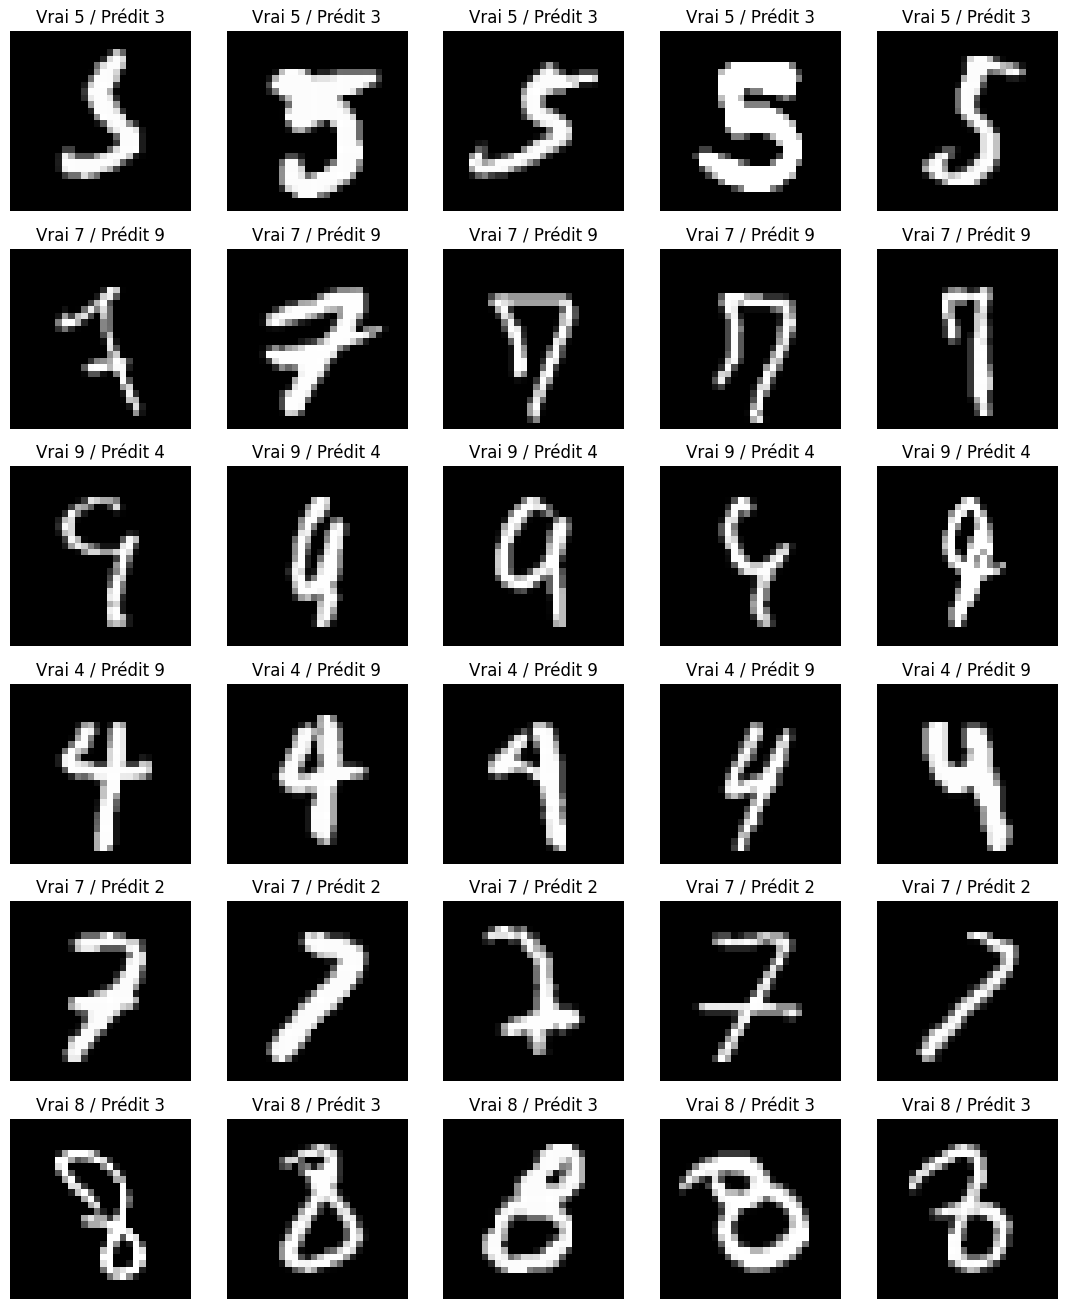

In [79]:
# =========================
# Affichage des erreurs les plus fréquentes
# =========================

import numpy as np
import matplotlib.pyplot as plt

# Si besoin, on récupère les prédictions du meilleur MLP2
params = best_mlp2["best_parameters"]

y_pred_best = predict_2_hidden(
    X_test_flat,
    params["A1"],
    params["b1"],
    params["A2"],
    params["b2"],
    params["A3"],
    params["b3"]
)

# Matrice de confusion
num_classes = 10
cm = np.zeros((num_classes, num_classes), dtype=int)

for true_label, pred_label in zip(y_test, y_pred_best):
    cm[true_label, pred_label] += 1

# Liste des confusions hors diagonale
confusions = []

for true_label in range(10):
    for pred_label in range(10):
        if true_label != pred_label and cm[true_label, pred_label] > 0:
            confusions.append((true_label, pred_label, cm[true_label, pred_label]))

confusions = sorted(confusions, key=lambda x: x[2], reverse=True)

print("Principales confusions :")
for true_label, pred_label, count in confusions[:10]:
    print(f"Vrai {true_label} prédit {pred_label} : {count} erreurs")


# =========================
# Afficher les exemples des confusions principales
# =========================

top_confusions = confusions[:6]   # tu peux mettre 4 si tu veux moins d'images
n_examples = 5                    # nombre d'images par confusion

plt.figure(figsize=(n_examples * 2.2, len(top_confusions) * 2.2))

plot_index = 1

for true_label, pred_label, count in top_confusions:
    indices = np.where((y_test == true_label) & (y_pred_best == pred_label))[0]

    for j, idx in enumerate(indices[:n_examples]):
        plt.subplot(len(top_confusions), n_examples, plot_index)
        plt.imshow(X_test[idx], cmap="gray")
        plt.title(f"Vrai {true_label} / Prédit {pred_label}")
        plt.axis("off")
        plot_index += 1

plt.tight_layout()
plt.show()

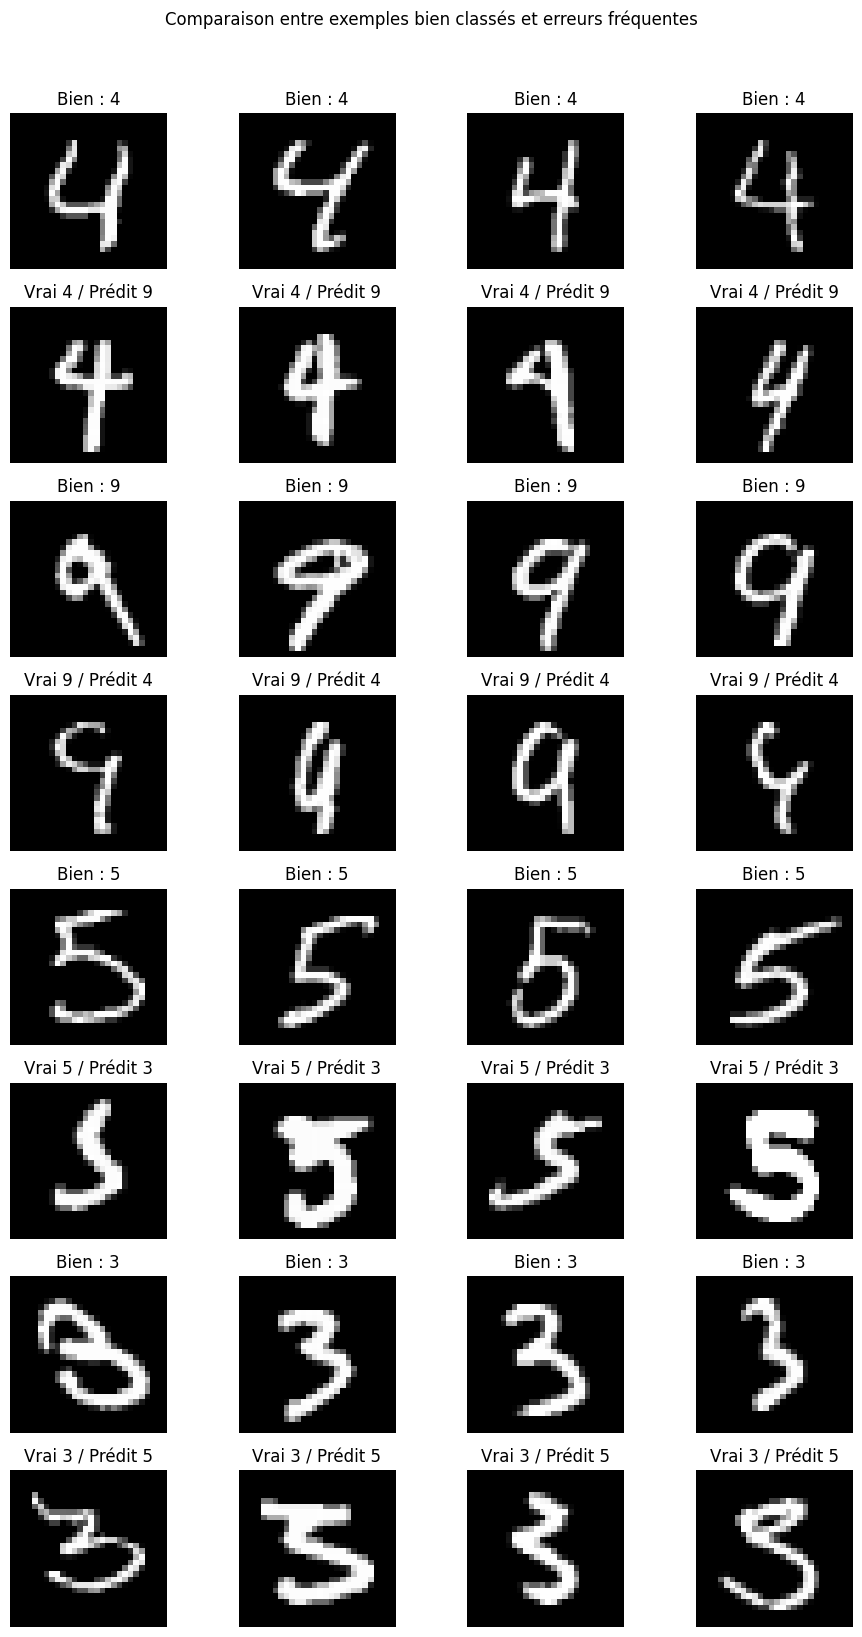

In [80]:
# =========================
# Figure unique : bien prédits vs erreurs ciblées
# =========================

selected_confusions = [
    (4, 9),
    (9, 4),
    (5, 3),
    (3, 5)
]

n_examples = 4

plt.figure(figsize=(n_examples * 2.4, len(selected_confusions) * 4))

plot_index = 1

for true_label, pred_label in selected_confusions:
    good_indices = np.where((y_test == true_label) & (y_pred_best == true_label))[0]
    wrong_indices = np.where((y_test == true_label) & (y_pred_best == pred_label))[0]

    # Bien prédits
    for j, idx in enumerate(good_indices[:n_examples]):
        plt.subplot(len(selected_confusions) * 2, n_examples, plot_index)
        plt.imshow(X_test[idx], cmap="gray")
        plt.title(f"Bien : {true_label}")
        plt.axis("off")
        plot_index += 1

    # Mal prédits
    for j, idx in enumerate(wrong_indices[:n_examples]):
        plt.subplot(len(selected_confusions) * 2, n_examples, plot_index)
        plt.imshow(X_test[idx], cmap="gray")
        plt.title(f"Vrai {true_label} / Prédit {pred_label}")
        plt.axis("off")
        plot_index += 1

plt.suptitle("Comparaison entre exemples bien classés et erreurs fréquentes", y=1.02)
plt.tight_layout()
plt.show()

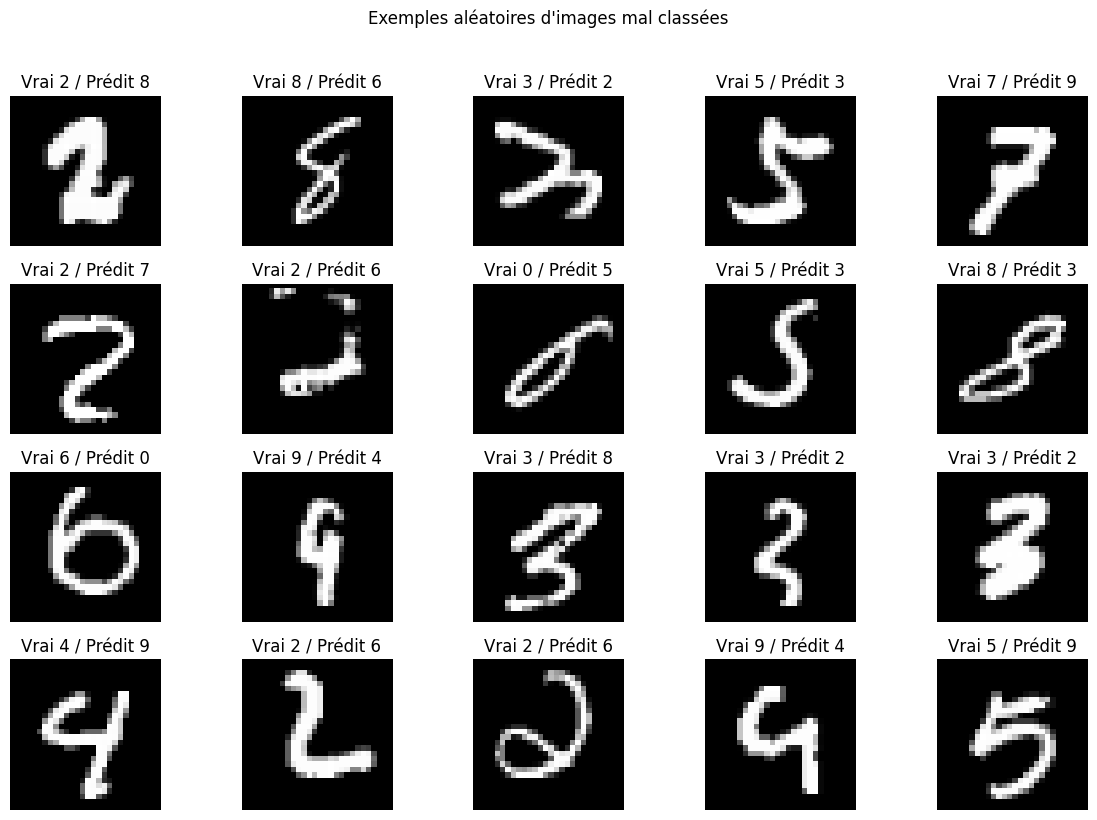

In [81]:
# =========================
# Erreurs aléatoires du meilleur modèle
# =========================

wrong_indices = np.where(y_pred_best != y_test)[0]

np.random.seed(42)
random_errors = np.random.choice(wrong_indices, size=20, replace=False)

plt.figure(figsize=(12, 8))

for j, idx in enumerate(random_errors):
    plt.subplot(4, 5, j + 1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"Vrai {y_test[idx]} / Prédit {y_pred_best[idx]}")
    plt.axis("off")

plt.suptitle("Exemples aléatoires d'images mal classées", y=1.02)
plt.tight_layout()
plt.show()

In [83]:
# =========================
# Erreurs rares
# =========================

rare_confusions = []

for true_label in range(10):
    for pred_label in range(10):
        if true_label != pred_label and 1 <= cm[true_label, pred_label] <= 5:
            rare_confusions.append((true_label, pred_label, cm[true_label, pred_label]))

print("Quelques confusions rares :")
for true_label, pred_label, count in rare_confusions[:20]:
    print(f"Vrai {true_label} prédit {pred_label} : {count} erreurs")

Quelques confusions rares :
Vrai 0 prédit 2 : 2 erreurs
Vrai 0 prédit 3 : 1 erreurs
Vrai 0 prédit 5 : 5 erreurs
Vrai 0 prédit 7 : 1 erreurs
Vrai 0 prédit 8 : 2 erreurs
Vrai 1 prédit 2 : 2 erreurs
Vrai 1 prédit 3 : 2 erreurs
Vrai 1 prédit 4 : 1 erreurs
Vrai 1 prédit 5 : 1 erreurs
Vrai 1 prédit 6 : 2 erreurs
Vrai 2 prédit 1 : 1 erreurs
Vrai 2 prédit 5 : 1 erreurs
Vrai 2 prédit 9 : 1 erreurs
Vrai 3 prédit 0 : 1 erreurs
Vrai 3 prédit 9 : 2 erreurs
Vrai 4 prédit 0 : 1 erreurs
Vrai 4 prédit 1 : 1 erreurs
Vrai 4 prédit 2 : 4 erreurs
Vrai 4 prédit 7 : 3 erreurs
Vrai 4 prédit 8 : 3 erreurs


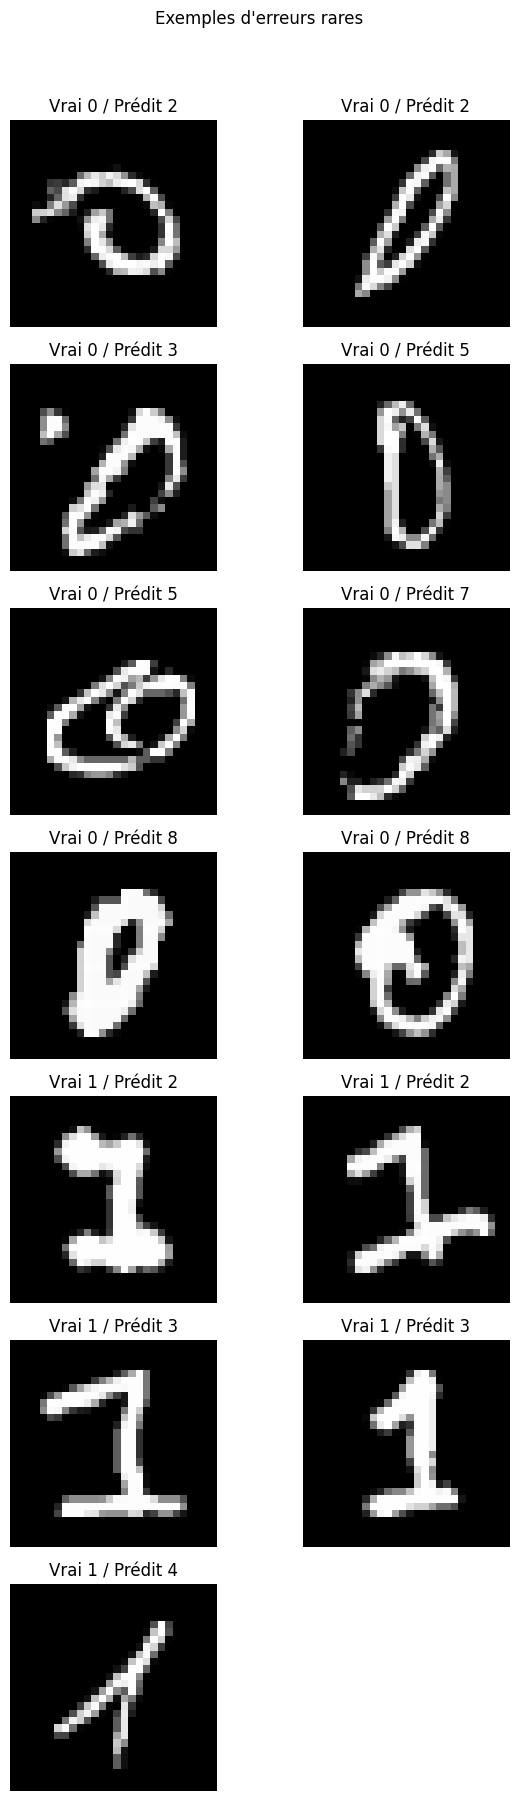

In [84]:
# =========================
# Afficher quelques erreurs rares
# =========================

np.random.seed(42)

selected_rare_confusions = rare_confusions[:8]  # tu peux changer le nombre
n_examples = 2

plt.figure(figsize=(n_examples * 3, len(selected_rare_confusions) * 2.5))

plot_index = 1

for true_label, pred_label, count in selected_rare_confusions:
    indices = np.where((y_test == true_label) & (y_pred_best == pred_label))[0]

    chosen_indices = indices[:n_examples]

    for idx in chosen_indices:
        plt.subplot(len(selected_rare_confusions), n_examples, plot_index)
        plt.imshow(X_test[idx], cmap="gray")
        plt.title(f"Vrai {true_label} / Prédit {pred_label}")
        plt.axis("off")
        plot_index += 1

plt.suptitle("Exemples d'erreurs rares", y=1.02)
plt.tight_layout()
plt.show()

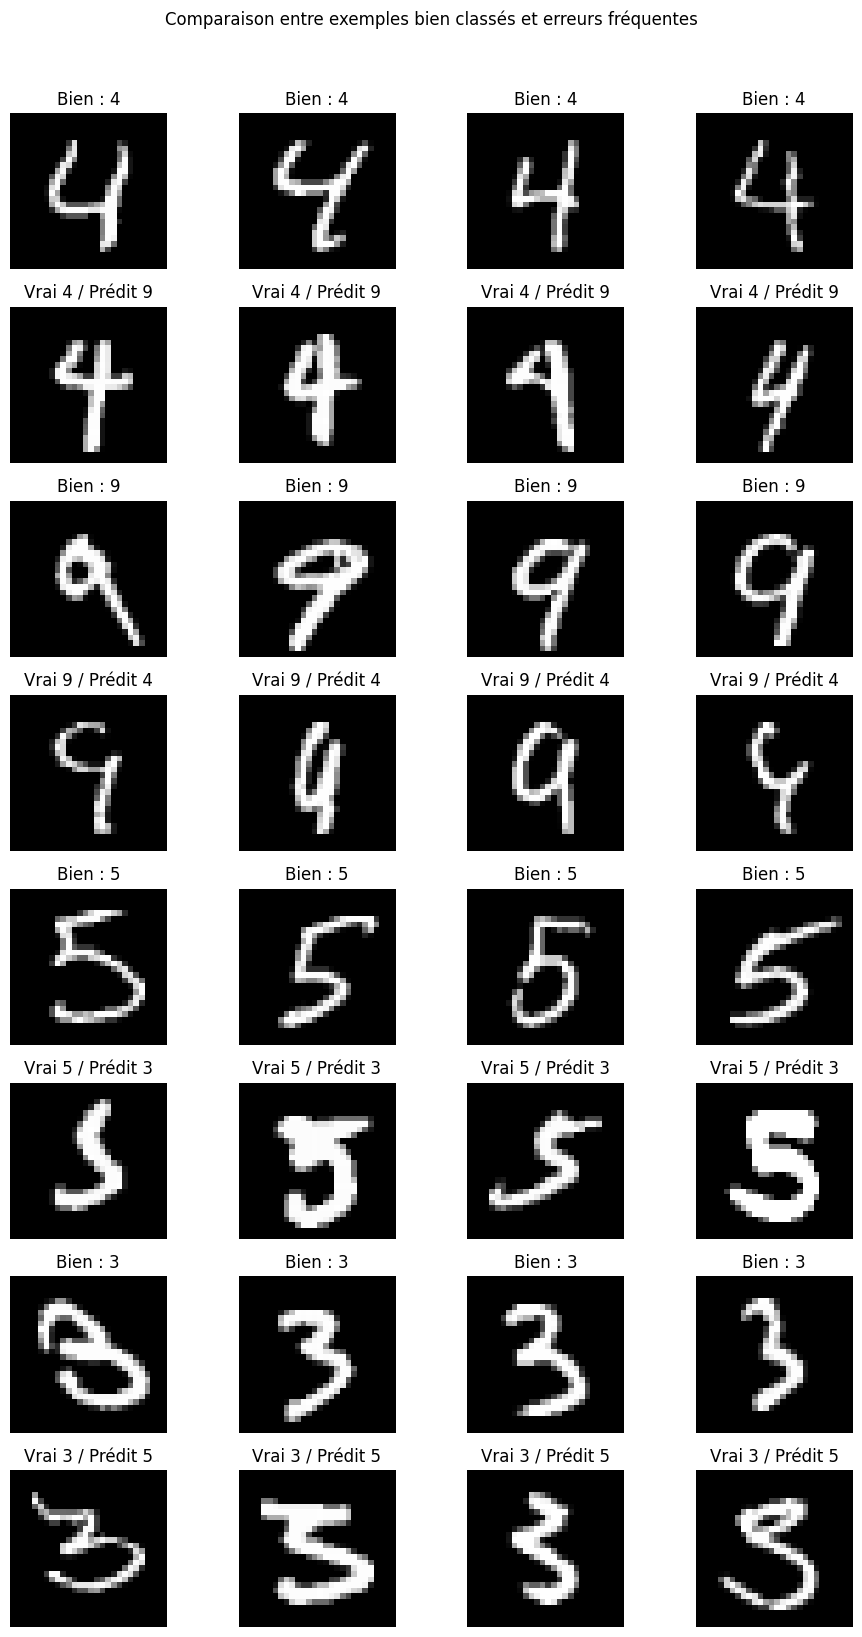

In [85]:
# =========================
# Figure unique : bien prédits vs erreurs ciblées
# =========================

selected_confusions = [
    (4, 9),
    (9, 4),
    (5, 3),
    (3, 5)
]

n_examples = 4

plt.figure(figsize=(n_examples * 2.4, len(selected_confusions) * 4))

plot_index = 1

for true_label, pred_label in selected_confusions:
    good_indices = np.where((y_test == true_label) & (y_pred_best == true_label))[0]
    wrong_indices = np.where((y_test == true_label) & (y_pred_best == pred_label))[0]

    # Bien prédits
    for j, idx in enumerate(good_indices[:n_examples]):
        plt.subplot(len(selected_confusions) * 2, n_examples, plot_index)
        plt.imshow(X_test[idx], cmap="gray")
        plt.title(f"Bien : {true_label}")
        plt.axis("off")
        plot_index += 1

    # Mal prédits
    for j, idx in enumerate(wrong_indices[:n_examples]):
        plt.subplot(len(selected_confusions) * 2, n_examples, plot_index)
        plt.imshow(X_test[idx], cmap="gray")
        plt.title(f"Vrai {true_label} / Prédit {pred_label}")
        plt.axis("off")
        plot_index += 1

plt.suptitle("Comparaison entre exemples bien classés et erreurs fréquentes", y=1.02)
plt.tight_layout()

# Sauvegarde de l'image
plt.savefig("comparaison_bien_classes_erreurs.png", dpi=300, bbox_inches="tight")

plt.show()

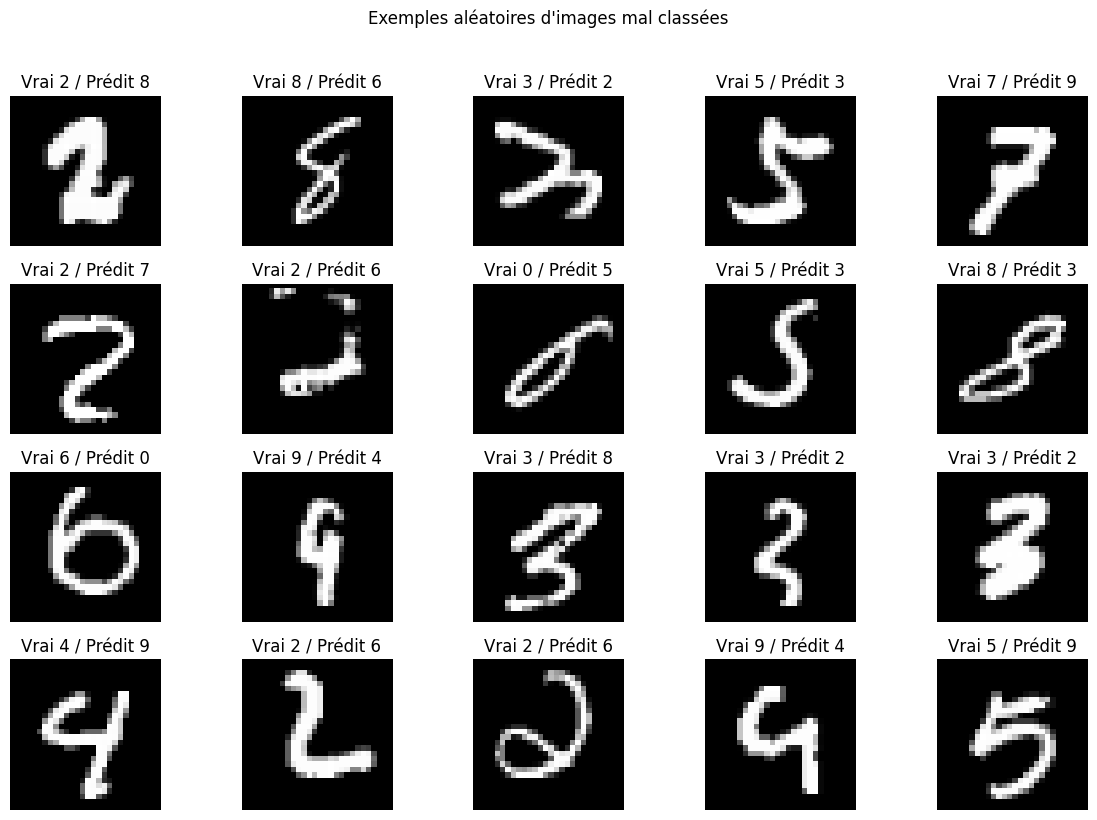

In [86]:
# =========================
# Erreurs aléatoires du meilleur modèle
# =========================

wrong_indices = np.where(y_pred_best != y_test)[0]

np.random.seed(42)
random_errors = np.random.choice(wrong_indices, size=20, replace=False)

plt.figure(figsize=(12, 8))

for j, idx in enumerate(random_errors):
    plt.subplot(4, 5, j + 1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"Vrai {y_test[idx]} / Prédit {y_pred_best[idx]}")
    plt.axis("off")

plt.suptitle("Exemples aléatoires d'images mal classées", y=1.02)
plt.tight_layout()

# Sauvegarde de l'image
plt.savefig("erreurs_aleatoires.png", dpi=300, bbox_inches="tight")

plt.show()